# Identificación de audios sintéticos & reales

En este archivo se realiza el análisis de los datos extraídos de 4000 audios, para clasificarlos en sinteticos (IA) o reales. También se tendrá en cuenta si factores como el acento, el genero o el modelo generador de audio tienen impacto en la clasificación.

URL del Git: https://github.com/txellbalada/Reto_IA

# 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from tqdm import tqdm
from google.colab import drive
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score, LearningCurveDisplay, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    recall_score,
    accuracy_score,
    recall_score,
    f1_score
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from datasets import Dataset, Audio, load_from_disk
import torch
import librosa
from transformers import AutoFeatureExtractor, ASTForAudioClassification, TrainingArguments, Trainer







In [2]:
!pip install evaluate
import evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Ruta de la carpeta
#ruta_base = "/content/drive/MyDrive/Reto_Telefonica/All_accents_csv/"
ruta_base = "/content/drive/MyDrive/00_Master/TFM/Reto_Telefonica/All_accents_csv/"

In [5]:
# Unificamos los CSVs para tener solo 1 dataframe con toda la información
archivos = glob.glob(ruta_base + "*.csv")

print("CSV encontrados:")
for a in archivos:
    print(a)

dfs = []

for archivo in archivos:

    # Leer CSV
    df = pd.read_csv(archivo)

    # Nombre del archivo
    nombre = os.path.basename(archivo).lower().strip()

    # LABEL

    if "real" in nombre:
        df["label"] = 0
    else:
        df["label"] = 1

    # ACCENT
    if "peruano" in nombre:
        df["accent"] = "peruano"

    elif "colombiano" in nombre:
        df["accent"] = "colombiano"

    elif "chileno" in nombre:
        df["accent"] = "chileno"

    elif "argentino" in nombre:
        df["accent"] = "argentino"

    else:
        df["accent"] = "desconocido"
        print("No se detectó acento en:", nombre)

    # GENERO
    if "genero_f" in df.columns:

        df["genero"] = np.where(
            df["genero_f"] == 1,
            "femenino",
            "masculino"
        )

    else:

        print("Warning: 'genero_f' no encontrada")
        df["genero"] = "unknown"

    # MODELO GENERADOR

    df["modelo_generador"] = "real"

    # Solo aplicar a sintéticos
    if df["label"].iloc[0] == 1:

        archivo_lower = df["archivo"].astype(str).str.lower()

        df.loc[
            archivo_lower.str.contains("tts-stargan", na=False),
            "modelo_generador"
        ] = "TTS-StarGAN"

        df.loc[
            archivo_lower.str.contains("tts-diff", na=False),
            "modelo_generador"
        ] = "TTS-Diff"

        df.loc[
            archivo_lower.str.contains("cyclegan", na=False),
            "modelo_generador"
        ] = "CycleGAN"

        df.loc[
            archivo_lower.str.contains("stargan", na=False)
            & ~archivo_lower.str.contains("tts-stargan", na=False),
            "modelo_generador"
        ] = "StarGAN"

        df.loc[
            archivo_lower.str.contains("diff", na=False)
            & ~archivo_lower.str.contains("tts-dif", na=False),
            "modelo_generador"
        ] = "Diff"

        df.loc[
            archivo_lower.str.contains("tts", na=False)
            & ~archivo_lower.str.contains("tts-stargan", na=False)
            & ~archivo_lower.str.contains("tts-dif", na=False),
            "modelo_generador"
        ] = "TTS"

    # Guardar dataframe
    dfs.append(df)

# UNIR TODO
df_unified = pd.concat(dfs, ignore_index=True)

print("\nShape final:")
print(df_unified.shape)

df_unified.head()



CSV encontrados:
/content/drive/MyDrive/00_Master/TFM/Reto_Telefonica/All_accents_csv/500peruano_dataset_features_sintetico.csv
/content/drive/MyDrive/00_Master/TFM/Reto_Telefonica/All_accents_csv/500peruano_dataset_features_real.csv
/content/drive/MyDrive/00_Master/TFM/Reto_Telefonica/All_accents_csv/500chileno_dataset_features_sintetico.csv
/content/drive/MyDrive/00_Master/TFM/Reto_Telefonica/All_accents_csv/500argentino_dataset_features_sintetico.csv
/content/drive/MyDrive/00_Master/TFM/Reto_Telefonica/All_accents_csv/500colombiano_dataset_features_sintetico.csv
/content/drive/MyDrive/00_Master/TFM/Reto_Telefonica/All_accents_csv/500colombiano_dataset_features_real.csv
/content/drive/MyDrive/00_Master/TFM/Reto_Telefonica/All_accents_csv/500argentino_dataset_features_real.csv
/content/drive/MyDrive/00_Master/TFM/Reto_Telefonica/All_accents_csv/500chileno_dataset_features_real.csv

Shape final:
(4000, 592)


,id_audio,archivo,label,genero_f,colombiano,chileno,argentino,peruano,modelo_cyclegan,modelo_diff,...,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr,accent,genero,modelo_generador
0,1,CycleGAN-pef_08421_00042078409-pef_01208_01247...,1,1,0,0,0,1,1,0,...,4761.71875,1335.937500,5916.015625,-0.121171,-1.659926,492.1875,4580.078125,peruano,femenino,CycleGAN
1,2,CycleGAN-pef_08421_00042078409-pef_03397_00805...,1,1,0,0,0,1,1,0,...,4093.75000,1810.546875,5324.218750,-0.099164,-1.290338,539.0625,3513.671875,peruano,femenino,CycleGAN
2,3,CycleGAN-pef_08421_00042078409-pef_07049_01353...,1,1,0,0,0,1,1,0,...,3882.81250,1744.140625,4939.453125,0.010095,-1.072997,515.6250,3195.312500,peruano,femenino,CycleGAN
3,4,CycleGAN-pef_08421_00042078409-pef_07508_01611...,1,1,0,0,0,1,1,0,...,4777.34375,2335.937500,5556.640625,-0.394409,-1.091107,531.2500,3220.703125,peruano,femenino,CycleGAN
4,5,CycleGAN-pef_08421_00569156593-pef_01208_01958...,1,1,0,0,0,1,1,0,...,2808.59375,1208.984375,5906.250000,0.294378,-1.419423,507.8125,4697.265625,peruano,femenino,CycleGAN


# 1. Exploracion de datos

In [6]:
# Paleta azul y morado
PALETTE = ["#3B82F6", "#800080"]

# Estilo general
sns.set_style("whitegrid")

In [7]:
#Principales estadisticos

# Informacion general
print("\nInformacion del dataset:")
df_unified.info()

# Dimensiones del dataset
print("\nShape del dataset:")
print(df_unified.shape)

# Valores nulos
print("\nValores nulos por columna:")
display(df_unified.isnull().sum())

# Estadisticas descriptivas
print("\nEstadisticas descriptivas:")
display(df_unified.describe())

# Variables categoricas
print("\nVariables categoricas:")
display(df_unified.describe(include='object'))

# Valores duplicados
print("\nValores duplicados:")
print(df_unified.duplicated().sum())

# Distribucion de clases
print("\nDistribucion REAL vs IA:")
display(df_unified["label"].value_counts())

# Distribucion por acento
print("\nDistribucion por acento:")
display(df_unified["accent"].value_counts())

# Distribucion cruzada
print("\nDistribucion acento vs label:")
display(pd.crosstab(df_unified["accent"], df_unified["label"]))


Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Columns: 592 entries, id_audio to modelo_generador
dtypes: float64(575), int64(13), object(4)
memory usage: 18.1+ MB

Shape del dataset:
(4000, 592)

Valores nulos por columna:


,0
id_audio,0
archivo,0
label,0
genero_f,0
colombiano,0
...,...
rolloff_mode,0
rolloff_iqr,0
accent,0
genero,0



Estadisticas descriptivas:


,id_audio,label,genero_f,colombiano,chileno,argentino,peruano,modelo_cyclegan,modelo_diff,modelo_stargan,...,rolloff_std,rolloff_min,rolloff_max,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,250.500000,0.500000,0.446000,0.250000,0.250000,0.250000,0.250000,0.090000,0.160000,0.090000,...,1797.933045,465.341797,7066.960938,3812.332031,2158.432129,5171.019043,-0.019963,-0.924487,3105.289062,3012.586914
std,144.355324,0.500063,0.497138,0.433067,0.433067,0.433067,0.433067,0.286218,0.366652,0.286218,...,250.959727,344.247761,412.273564,1024.508230,663.907106,709.618057,0.564540,0.696364,1957.921171,856.862523
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,951.699335,78.125000,4328.125000,906.250000,501.953125,2072.265625,-2.118632,-1.787087,101.562500,464.843750
25%,125.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1626.158021,156.250000,6875.000000,2921.875000,1726.074219,4814.453125,-0.370442,-1.391914,1406.250000,2499.023438
50%,250.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1817.097402,398.437500,7140.625000,3789.062500,2039.062500,5304.687500,-0.039119,-1.130978,2554.687500,3136.718750
75%,375.250000,1.000000,1.000000,0.250000,0.250000,0.250000,0.250000,0.000000,0.000000,0.000000,...,1978.350659,664.062500,7351.562500,4664.062500,2453.125000,5640.625000,0.330424,-0.672626,5150.390625,3621.093750
max,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2580.264631,2273.437500,7867.187500,6171.875000,5429.687500,7218.750000,2.000753,4.157973,7585.937500,5515.625000



Variables categoricas:


...

,count
label,
1,2000
0,2000



Distribucion por acento:


,count
accent,
peruano,1000
chileno,1000
argentino,1000
colombiano,1000



Distribucion acento vs label:


label,0,1
accent,,
argentino,500,500
chileno,500,500
colombiano,500,500
peruano,500,500


In [8]:
#Valores nulls

df_unified.isna().sum().sort_values(ascending=False).head(20)

,0
flatness_kurtosis,0
flatness_skew,0
flatness_q3,0
flatness_q1,0
flatness_median,0
flatness_max,0
flatness_min,0
flatness_std,0
flatness_mean,0
contrast_7_iqr,0


## 1.1. Distribucion por acento y clase

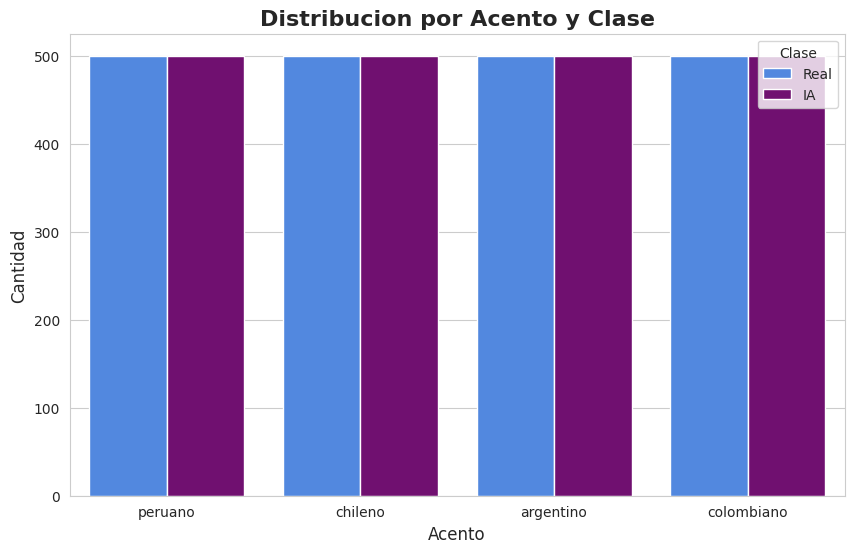

In [9]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df_unified,
    x="accent",
    hue="label",
    palette=PALETTE
)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Real", "IA"], title="Clase")

plt.title("Distribucion por Acento y Clase", fontsize=16, fontweight="bold")
plt.xlabel("Acento", fontsize=12)
plt.ylabel("Cantidad", fontsize=12)

plt.show()

## 1.2. Histograma RMS

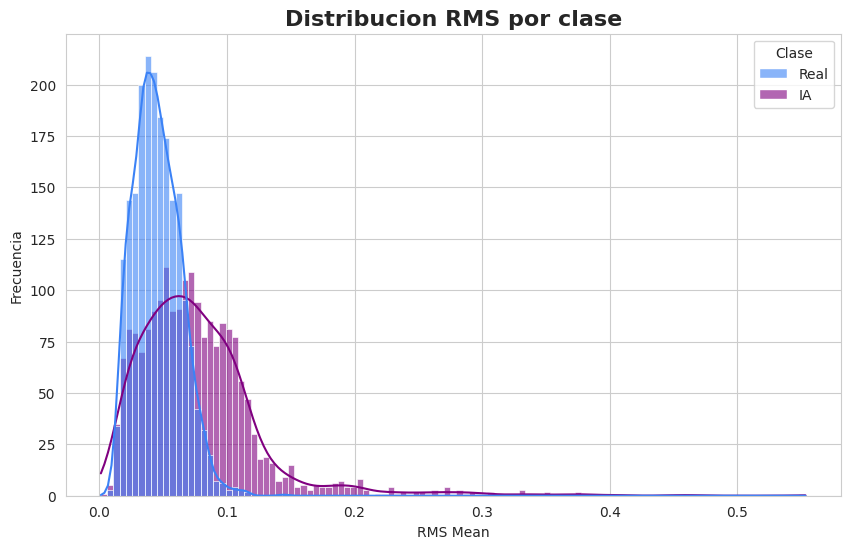

In [10]:
plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=df_unified,
    x="rms_mean",
    hue="label",
    kde=True,
    palette=PALETTE,
    alpha=0.6
)

#Leyenda
leyenda = ax.get_legend()
leyenda.set_title("Clase")
nuevas_etiquetas = ["Real", "IA"]
for texto, nueva_etiqueta in zip(leyenda.texts, nuevas_etiquetas):
    texto.set_text(nueva_etiqueta)

plt.title("Distribucion RMS por clase", fontsize=16, fontweight="bold")
plt.xlabel("RMS Mean")
plt.ylabel("Frecuencia")

plt.show()

El RMS muestra que las voces reales presentan niveles de energía más concentrados y estables, mientras que las voces sintéticas tienen una distribución más dispersa y con valores extremos. Esto sugiere que los audios generados por IA presentan patrones energéticos menos naturales, ver el comportamiento de este feature es importante para la detección de las voces generadas por IA.

## 1.3. Histograma ZCR

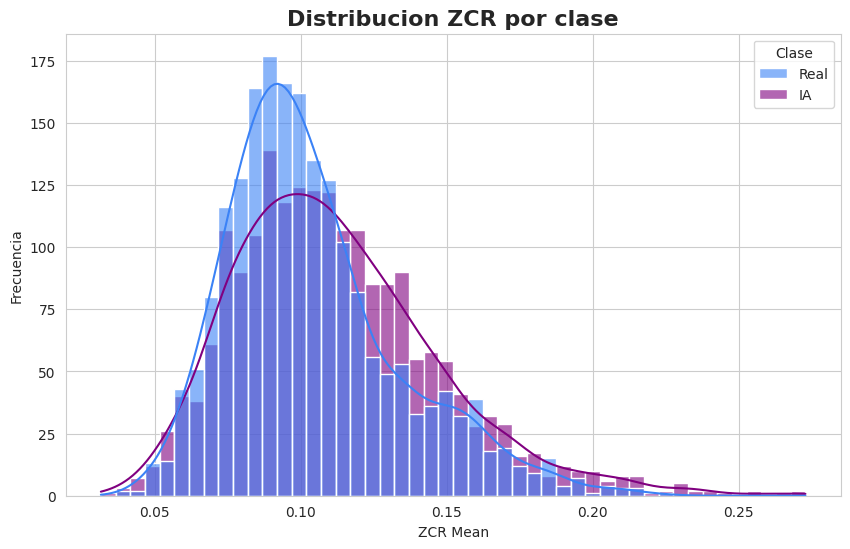

In [11]:
plt.figure(figsize=(10,6))

ax= sns.histplot(
    data=df_unified,
    x="zcr_mean",
    hue="label",
    kde=True,
    palette=PALETTE,
    alpha=0.6
)

#Leyenda
leyenda = ax.get_legend()
leyenda.set_title("Clase")
nuevas_etiquetas = ["Real", "IA"]
for texto, nueva_etiqueta in zip(leyenda.texts, nuevas_etiquetas):
    texto.set_text(nueva_etiqueta)

plt.title("Distribucion ZCR por clase", fontsize=16, fontweight="bold")
plt.xlabel("ZCR Mean")
plt.ylabel("Frecuencia")

plt.show()

El histograma de ZCR muestra que las voces sintéticas presentan una mayor dispersión y valores ligeramente más altos que las voces reales. Mientras las voces reales mantienen una distribución más concentrada y estable alrededor de ciertos rangos, los audios generados por IA exhiben una variabilidad más amplia en la señal.

Esto sugiere que los modelos de síntesis producen comportamientos acústicos menos naturales, generando:

- transiciones vocales más artificiales
- microvariaciones inconsistentes
- patrones más irregulares en la señal de audio

Por ello, el ZCR resulta útil para identificar diferencias en naturalidad y estabilidad entre voces reales y voces sintéticas.

## 1.4. Boxplot MFCC 1

/tmp/ipykernel_4077/371815130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


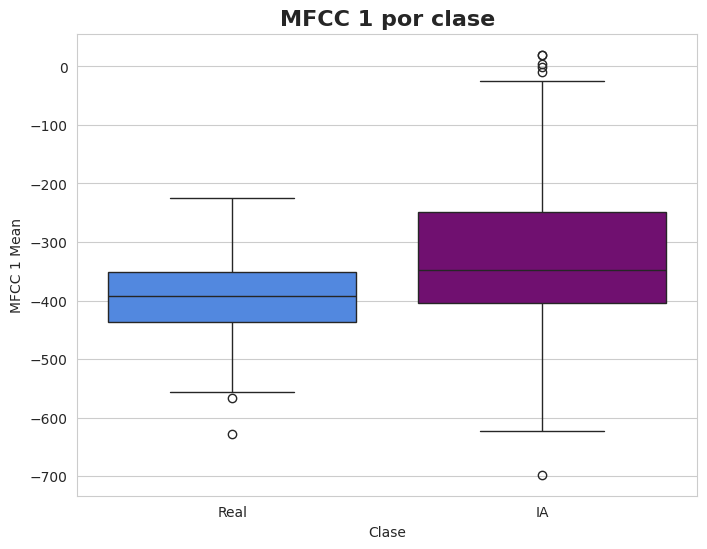

In [12]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_unified,
    x="label",
    y="mfcc_1_mean",
    palette=PALETTE
)

plt.xticks([0,1], ["Real", "IA"])

plt.title("MFCC 1 por clase", fontsize=16, fontweight="bold")
plt.xlabel("Clase")
plt.ylabel("MFCC 1 Mean")

plt.show()

Las voces sintéticas presentan una mayor dispersión y variabilidad en los valores del coeficiente, mientras que las voces reales mantienen una distribución más concentrada y estable.

Además, los audios IA muestran una presencia más marcada de valores extremos (outliers), lo que sugiere comportamientos acústicos menos consistentes. Esto puede deberse a que los modelos de síntesis no logran reproducir completamente las microvariaciones naturales del timbre y la resonancia humana.

## 1.5. Boxplot RMS Mean

/tmp/ipykernel_4077/593191135.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


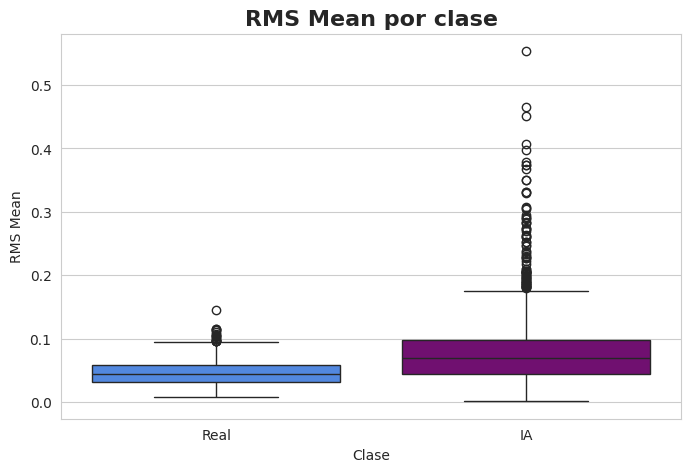

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="rms_mean",
    data=df_unified,
    palette=PALETTE
)

plt.xticks([0, 1], ["Real", "IA"])
plt.title("RMS Mean por clase", fontsize=16, fontweight="bold")
plt.xlabel("Clase")
plt.ylabel("RMS Mean")

plt.show()

El rms_mean parece ser un buen indicador de diferencia. Los audios de IA muestran una mayor dispersión y una tendencia a tener outliers con valores de energía más extremos, lo que podría reflejar un comportamiento menos natural en su perfil de energía en comparación con los audios humanos reales.

## 1.6. Boxplot MFCC 1

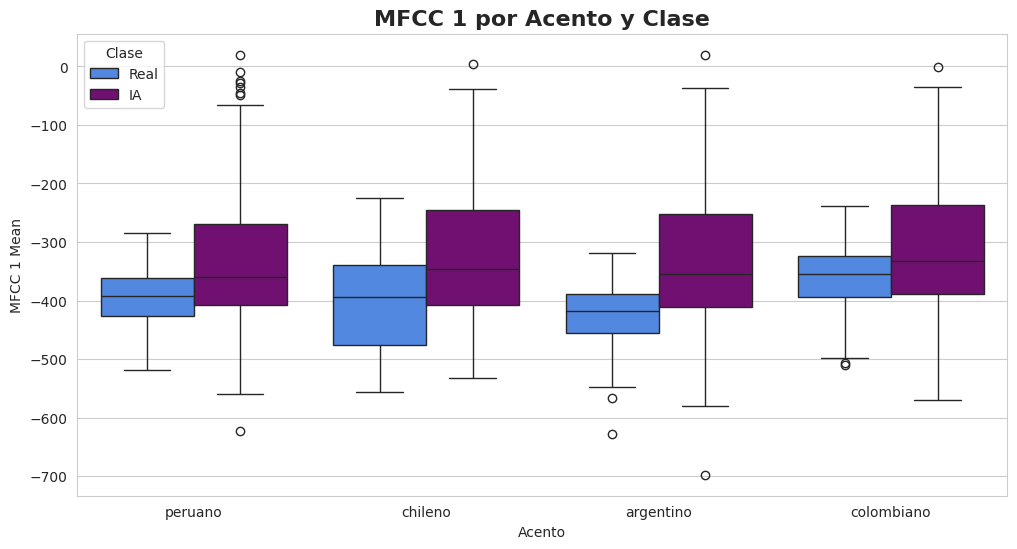

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_unified,
    x="accent",
    y="mfcc_1_mean",
    hue="label",
    palette=PALETTE
)

plt.title("MFCC 1 por Acento y Clase", fontsize=16, fontweight="bold")
plt.xlabel("Acento")
plt.ylabel("MFCC 1 Mean")

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Real", "IA"], title="Clase")

plt.show()

La gráfica compara la distribución de MFCC 1 Mean según el acento y el tipo de audio (real o IA).

Este análisis permite verificar si las diferencias observadas provienen realmente de la síntesis de voz o si el modelo podría estar aprendiendo patrones asociados al acento.

En los tres acentos se observa una tendencia similar: los audios generados por IA presentan una mayor dispersión y valores más altos de MFCC 1 en comparación con los audios reales. Esto indica que la feature logra capturar diferencias relacionadas con la generación sintética de voz de manera relativamente consistente entre acentos.

Sin embargo, también existen diferencias entre colombiano, chileno y argentino, lo que confirma que el acento influye en las características acústicas del dataset. Por ello, es importante considerar esta variable durante el entrenamiento y evaluación del modelo para evitar sesgos y asegurar que el sistema aprenda a detectar síntesis de voz y no únicamente diferencias de pronunciación o entonación.

## 1.7. PCA Visualization

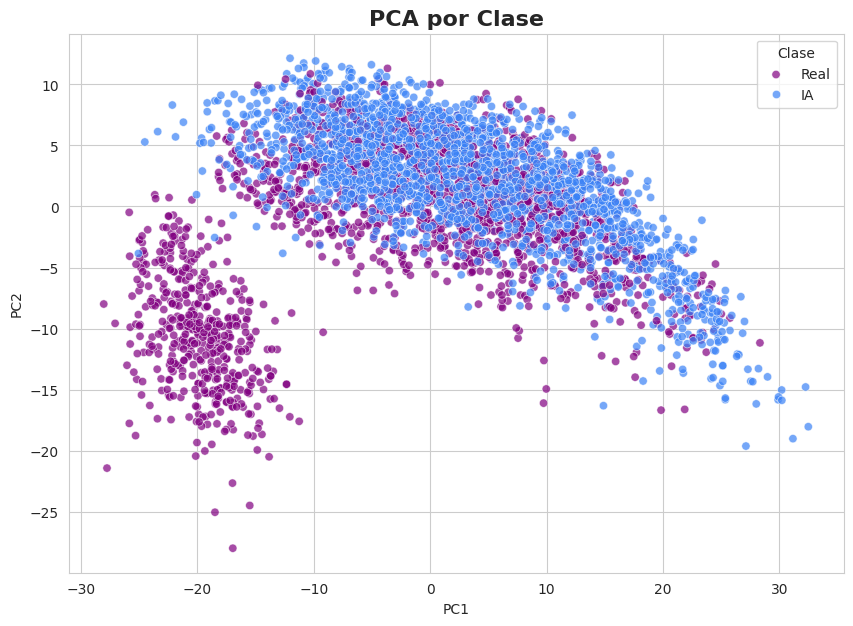

In [15]:
X = df_unified.select_dtypes(include=['float64', 'int64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["label"] = df_unified["label"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    palette=PALETTE,
    alpha=0.7
)

plt.title("PCA por Clase", fontsize=16, fontweight="bold")

plt.legend(labels=["Real", "IA"], title="Clase")

plt.show()

La visualización PCA permite reducir todas las features acústicas del dataset a dos componentes principales (PC1 y PC2) para observar de forma gráfica cómo se distribuyen los audios reales y sintéticos. Este análisis es útil para identificar si las features extraídas contienen información suficiente para diferenciar ambas clases.

En el gráfico se observa una separación parcial entre los audios reales y los generados por IA. Los audios sintéticos presentan una mayor concentración en ciertas regiones del espacio, mientras que los audios reales muestran agrupaciones más dispersas, especialmente en la zona izquierda inferior del gráfico.

Sin embargo, también existe una superposición considerable entre ambas clases, lo que indica que algunas voces sintéticas comparten características acústicas similares a las voces reales.

Esto sugiere que las features utilizadas sí capturan diferencias relevantes, aunque no son suficientes para lograr una separación perfecta por sí solas.

## 1.8. PCA por acento

Text(0.5, 1.0, 'PCA por acento')

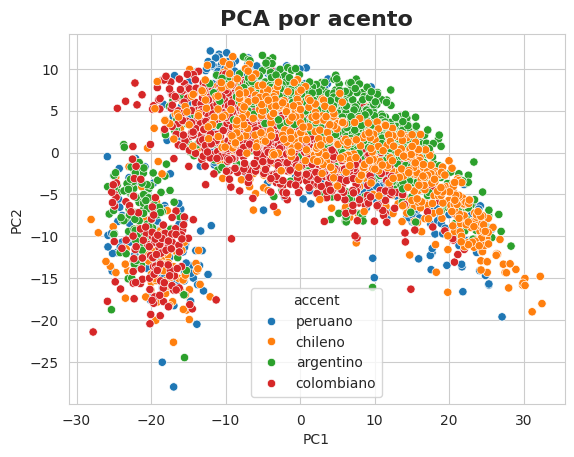

In [16]:
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=df_unified["accent"]
)

plt.title("PCA por acento", fontsize=16, fontweight="bold")

En el gráfico se observa que los acentos presentan ciertas agrupaciones y tendencias dentro del espacio generado por PCA, especialmente en algunas regiones donde predomina un acento sobre los demás. Esto indica que las features utilizadas, como MFCC y características espectrales, también capturan información relacionada con la pronunciación y entonación propias de cada país.

Sin embargo, los grupos no están completamente separados y existe bastante superposición entre ellos, lo que sugiere que el dataset mantiene cierta diversidad y no depende únicamente del acento.

Aun así, este resultado confirma la importancia de considerar la variable de acento durante el entrenamiento y evaluación del modelo para evitar sesgos y asegurar que el sistema aprenda patrones de síntesis de voz y no únicamente diferencias dialectales.

## 1.9. PCA por género

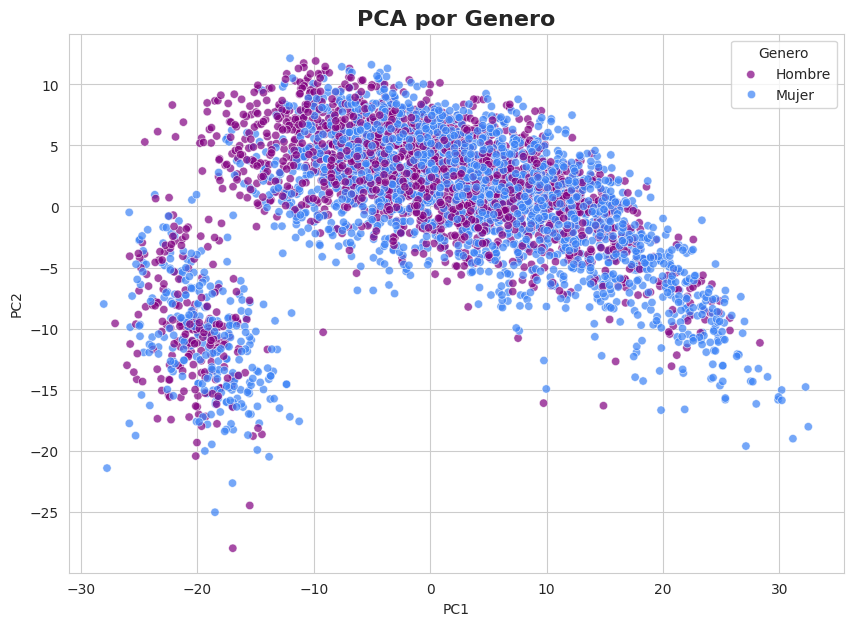

In [17]:
pca_df_genero = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df_genero["genero_f"] = df_unified["genero_f"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df_genero,
    x="PC1",
    y="PC2",
    hue="genero_f",
    palette=PALETTE,
    alpha=0.7
)

plt.title("PCA por Genero", fontsize=16, fontweight="bold")
plt.legend(labels=["Hombre", "Mujer"], title = "Genero")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

Hay una separación parcial, con las voces masculinas tendiendo hacia valores mayores del PC2, apesar de ello, los puntos de ambos géneros están en gran medida entremezclados, lo que sugiere que el género por sí solo, no conduce a perfiles acústicos claramente distintos.

## 1.10. Medias de las MFCC por tipo de audio

MFCC 1: La Energía (El volumen)

MFCC 2 al 4: La Forma "Gruesa" (Timbre y Fonemas)
Estos son los más importantes para identificar qué se está diciendo y quién habla. Representan las variaciones de baja frecuencia en el espectro.

MFCC 2: Representa el balance entre frecuencias bajas y altas.

MFCC 3 y 4: Están muy relacionados con los formantes (las resonancias de tu boca al decir letras como la "A" o la "U").

*Los modelos de IA suelen ser muy buenos replicando estos porque son esenciales para que la voz se entienda.*

MFCC 5 al 8: Detalles de Resonancia
Estos capturan cambios más finos en el espectro. Describen matices de la garganta y la posición de la lengua.

*Aquí es donde la IA empieza a tener problemas. A veces, los sintetizadores generan resonancias "metálicas" o demasiado perfectas que se reflejan en estos coeficientes intermedios.*

MFCC 9 al 12: Detalles de Alta Frecuencia (Artefactos de la IA)
Estos representan variaciones muy rápidas y finas en el espectro de frecuencias.

*Capturan texturas sutiles, como el aire al pronunciar una "S" o pequeñas irregularidades en la voz humana. La mayoría de los modelos de IA (especialmente los más antiguos o ligeros) fallan en replicar la complejidad de las altas frecuencias*

In [18]:
mfcc_mean_cols = [col for col in df_unified.columns if col.startswith('mfcc_') and col.endswith('_mean')]

# Group by label and calculate the mean for each MFCC column
mfcc_means_table = df_unified.groupby('label')[mfcc_mean_cols].mean()

# Rename the index for better readability
mfcc_means_table.index = mfcc_means_table.index.map({0: 'Real', 1: 'IA'})

# Transpose the table
mfcc_means_table_transposed = mfcc_means_table.T

# Add a new column with the difference between 'Real' and 'IA' means
mfcc_means_table_transposed['Difference (Real - IA)'] = mfcc_means_table_transposed['Real'] - mfcc_means_table_transposed['IA']

# Add a new column with the percentage difference relative to 'Real'
mfcc_means_table_transposed['Percentage Diff (vs Real)'] = (((mfcc_means_table_transposed['Real'] - mfcc_means_table_transposed['IA']) / mfcc_means_table_transposed['Real']) * 100).map('{:.2f}%'.format)

print("Tabla de Medias de MFCC por Tipo de Audio (Transpuesta con Diferencia y %):")
display(mfcc_means_table_transposed)

Tabla de Medias de MFCC por Tipo de Audio (Transpuesta con Diferencia y %):


label,Real,IA,Difference (Real - IA),Percentage Diff (vs Real)
mfcc_1_mean,-395.599254,-331.440452,-64.158802,16.22%
mfcc_2_mean,68.547794,70.393739,-1.845945,-2.69%
mfcc_3_mean,3.433135,1.374463,2.058672,59.96%
mfcc_4_mean,18.569901,18.019352,0.550549,2.96%
mfcc_5_mean,6.291284,3.072034,3.219250,51.17%
mfcc_6_mean,0.903223,-1.521630,2.424853,268.47%
mfcc_7_mean,-1.754835,-4.175640,2.420805,-137.95%
mfcc_8_mean,-6.678689,-9.181475,2.502786,-37.47%
mfcc_9_mean,-2.063851,-4.187461,2.123611,-102.90%
mfcc_10_mean,-0.853801,-4.739376,3.885575,-455.09%


*   Los MFCCs de baja orden
(1-4) son relativamente bien replicados por la IA, aunque MFCC 1 y 3 ya muestran algunas diferencias.
*   Las diferencias se acentúan a medida que subimos en el orden de los MFCCs, especialmente a partir del MFCC 5.
*   Los MFCCs de alta orden (9-13) son donde se encuentran las mayores discrepancias, con audios de IA mostrando valores muy diferentes a los reales. Esto corrobora la idea de que la IA lucha por replicar los detalles finos y la imperfección natural de la voz humana, dejando artefactos detectables en estas frecuencias más altas.

##1.11 Correlaciones

Revisaremos las correlaciones más altas para ver en qué porcentaje nuestras variables pueden tener multicolinealidad.

In [19]:
umbral_correlacion = 0.90 # Revisaremos aquellas variables que tienen umbral de correlación superior al 90%

# 1. Calcular la matriz de correlación de Pearson
# Usamos .abs() porque una correlación de -0.95 es igual de problemática que una de +0.95
print("Calculando matriz de correlación...")
corr_matrix = X.corr().abs()

# 2. Seleccionar solo el triángulo superior de la matriz
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Encontrar las columnas que superan el umbral con alguna otra variable
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > umbral_correlacion)]

print(f"Se detectaron {len(to_drop)} variables altamente correlacionadas (>{umbral_correlacion}).")

# 4. Inspeccionamos los pares conflictivos antes de borrar
pares_alta_corr = []
for col in to_drop:
    # Buscar con qué variables estaba altamente correlacionada esta columna
    correlacionadas_con_col = upper_tri.index[upper_tri[col] > umbral_correlacion].tolist()
    for corr_col in correlacionadas_con_col:
        valor_corr = upper_tri.loc[corr_col, col]
        pares_alta_corr.append((corr_col, col, valor_corr))

print("\nEjemplos de pares altamente correlacionados:")
# Mostrar solo los 10 primeros para no saturar la pantalla
for par in pares_alta_corr[:10]:
    print(f" - '{par[0]}' y '{par[1]}' (Correlación: {par[2]:.4f})")


Calculando matriz de correlación...
Se detectaron 86 variables altamente correlacionadas (>0.9).

Ejemplos de pares altamente correlacionados:
 - 'zcr_mean' y 'zcr_q3' (Correlación: 0.9204)
 - 'zcr_skew' y 'zcr_kurtosis' (Correlación: 0.9376)
 - 'zcr_q3' y 'zcr_iqr' (Correlación: 0.9643)
 - 'rms_std' y 'rms_max' (Correlación: 0.9381)
 - 'rms_mean' y 'rms_q3' (Correlación: 0.9386)
 - 'rms_mean' y 'rmse_manual' (Correlación: 0.9621)
 - 'rms_q3' y 'rmse_manual' (Correlación: 0.9600)
 - 'mfcc_1_min' y 'mfcc_1_mode' (Correlación: 0.9825)
 - 'mfcc_3_mean' y 'mfcc_3_q1' (Correlación: 0.9082)
 - 'mfcc_5_mean' y 'mfcc_5_median' (Correlación: 0.9135)


In [20]:
    #Eliminamos las 86 variables con alta correlación (variable de la derecha)
    # Backup por si aca
    df_unified_backup = df_unified.copy()

    df_unified = df_unified.drop(columns=to_drop, errors='ignore')

    # 3. Imprimimos el log de auditoría
    print(f"   Tamaño original (df_unified_backup): {df_unified_backup.shape[1]} columnas.")
    print(f"   Nuevo tamaño (df_unified): {df_unified.shape[1]} columnas.")
    print(f"   El DataFrame original se mantiene a salvo en 'df_unified_backup'.")

   Tamaño original (df_unified_backup): 592 columnas.
   Nuevo tamaño (df_unified): 506 columnas.
   El DataFrame original se mantiene a salvo en 'df_unified_backup'.


Por que eliminar estas variables muy correlacionadas:

Interpretabilidad: En modelos de árboles, cuando tienes variables correlacionadas, el Feature Importance se divide entre ambas, haciendo que parezcan menos importantes de lo que son. Al quitar una, la importancia se concentra y el gráfico de importancia es más claro.

Eficiencia: XGBoost entrenará más rápido y ocupará menos memoria.

Generalización: Menos variables suelen significar un modelo menos propenso a memorizar ruido aleatorio del dataset (Overfitting).

# 2. Metodología

## 2.1 Hipótesis

Los algoritmos de generación de voz sintética introducen artefactos medibles en el dominio espectral y de energía, por lo que se hipotetiza que los modelos predictivos no lineales podrán identificar estos patrones latentes para clasificar con éxito los audios como reales o sintéticos.
Sin embargo, la robustez de esta clasificación variará en función de los siguientes factores:

*  1. Generalización por Acento: El recall del modelo disminuirá significativamente al enfrentarse a audios de acentos con los que no ha sido entrenado.
*  2. Robustez ante el Modelo Generador: La dificultad de detección variará según el algoritmo de síntesis utilizado, siendo algunas arquitecturas generativas más propensas a camuflar sus artefactos acústicos.
*  3. Disparidad por Género: Se hipotetiza que el modelo NO presentará un sesgo demográfico, mostrando un peor rendimiento general con áudios con voces femeninas dado que los datos con los cuales habrá sido entrenados serán balanceados.  


## 2.2 Métricas de evaluación

Dado que nos enfrentamos en el ámbito de la ciberseguridad, -predecir si un dato es real o fake- el accuracy no es la métrica más importante dado dado que asume que todos los errores tienen el mismo coste. Nuestro objetivo será minimizar los Falsos Negativos — audios generados por IA que logran evadir el sistema y son clasificados como reales—, ya que representan una brecha de seguridad crítica.Por ello, la métrica de mayor relevancia es el **Recall**.  

También se revisará:

*  1. Análisis de Sesgo de dialecto (Recall por Acento): Se evaluará el modelo desglosado por cada topología de acento para comprobar si la variabilidad de cada acento afecta al rendimiento de un modelo. Por ello, también se rejecutará el modelo con un acento con el cual NO habrá sido entrenado (Evaluación de Generalización Out-of-Distribution (OoD)), el acento peruano, para confirmar que su rendimiento persiste con este nuevo acento.

*  2. Análisis de Sesgo Demográfico (Recall por Género): Se evaluará el modelo desglosado por audios de locutores masculinos y femeninos para comprobar si la tiene menor rendimiento en el caso del áudios de género femenido (ver punto 2.1 de hipótesis)

*  3. Robustez Arquitectónica (Recall por Modelo Generador): Se analizará el desempeño frente a las distintas tecnologías utilizadas para sintetizar las muestras de áudio falso para identificar si el modelo tiene "puntos ciegos" frente a algoritmos de generación específicos.

## 2.3 Modelos

Se aplicarán diferentes modelos, con complejidad progresiva:

*  1. Random Forest: Se inicia con este modelo para tener un punto de referencia en las principales métricas de evaluación como las features que más aportan al modelo. Es un modelo rápido de entrenar y al ser basado en árboles de decisiones tiene una resistencia intrínseca al sobreajuste (overfitting).

*  2. XGBoost: Es un modelo más complejo y adecuado para el caso del proyecto, pero más lento su procesamiento. Esperamos ver diferencias tanto en las medidas de recall y f1 de los modelos como en rendimiento de este, pero también es más costoso su entreno y fitting.

*  3. Arquitectura Transformer: Es el modelo estrella en el mercado para el procesamiento de audio actual y detección e fakes. Estos tienen un mecanismo de self-attention que les permite ser capaces de procesar la secuencia y comprender las dependencias temporales a largo plazo de un audio, detectando micro-artefactos sintéticos en la línea temporal que los enfoques estadísticos de modelos tabulares como XGBOOST podrían pasar por alto.

Observación: Se ha prescindido del uso de Redes Neuronales Convolucionales (CNN) para capturar relaciones más complejas, dado que se ha priorizado la ejecución de Transformers.


## 2.4 Gestión del Overfitting y Dimensionalidad:

La relación entre la alta dimensionalidad (600 características) y el tamaño del dataset (3,000 muestras) plantea, en teoría, un riesgo de sobreajuste (overfitting). No obstante, este riesgo se ha mitigado mediante las propiedades intrínsecas de los modelos seleccionados:

*   Random Forest: Utiliza feature randomness (muestreo aleatorio de variables), lo que garantiza que los árboles no dependan de un conjunto reducido de características redundantes, forzando al modelo a aprender patrones diversos.

*   XGBoost: Su arquitectura es robusta ante la multicolinealidad; ante variables altamente correlacionadas, el algoritmo selecciona la que maximiza la ganancia de información en cada nodo. Además, incorpora regularización L1 (Lasso) y L2 (Ridge), que penaliza la complejidad excesiva y ayuda a simplificar la estructura de los árboles.

*   Transformers (AST): Implementa mecanismos de regularización nativos como Dropout y Weight Decay (0.01). El enfoque de Fine-tuning sobre un modelo pre-entrenado funciona como un ancla de conocimiento, permitiendo que el modelo generalice patrones acústicos universales en lugar de memorizar el ruido específico del dataset actual.

Finalmente, se descartó el uso de PCA para preservar la interpretabilidad de las características acústicas originales, permitiendo identificar qué descriptores (como los MFCC o el ZCR) son los más determinantes en la detección de audios sintéticos.

## 2.5 Preparación datasets de train test



In [21]:
# DF excluyendo los peruanos
df_sin_peruano = df_unified[df_unified['peruano'] == 0].copy()

# DF solo peruano para probar al final
df_solo_peruano = df_unified[df_unified['peruano'] == 1].copy()

# Verificación de los tamaños
print(f"Audios para Train/Validation (sin acento peruano): {df_sin_peruano.shape[0]} filas")
print(f"Audios reservados para Test de Generalización (solo peruano): {df_solo_peruano.shape[0]} filas")

Audios para Train/Validation (sin acento peruano): 3000 filas
Audios reservados para Test de Generalización (solo peruano): 1000 filas


In [22]:
# Eliminamos columnas de metadatos para evitar sesgos
df_model = df_sin_peruano.copy()

columnas_a_eliminar = [
    "label",
    "archivo",
    "id_audio",
    "accent",
    "colombiano",
    "chileno",
    "argentino",
    "peruano",
    "modelo_cyclegan",
    "modelo_diff",
    "modelo_stargan",
    "modelo_tts_dif",
    "modelo_tts_stargan",
    "modelo_tts",
    "genero_f",
    "genero",
    "modelo_generador"
]

X = df_model.drop(columns=columnas_a_eliminar, errors="ignore")

y = df_model["label"]

# Verificar columnas restantes
print("Columnas restantes:")
print(X.columns)

# Ver primeras filas
print("\nPrimeras filas de X:")
display(X.head())

# Ver target
print("\nPrimeras filas de y:")
display(y.head())

Columnas restantes:
Index(['duracion_seg', 'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max',
       'zcr_median', 'zcr_q1', 'zcr_skew', 'zcr_mode', 'rms_mean',
       ...
       'flatness_q3', 'flatness_skew', 'rolloff_std', 'rolloff_min',
       'rolloff_max', 'rolloff_q1', 'rolloff_q3', 'rolloff_kurtosis',
       'rolloff_mode', 'rolloff_iqr'],
      dtype='object', length=489)

Primeras filas de X:


,duracion_seg,zcr_mean,zcr_std,zcr_min,zcr_max,zcr_median,zcr_q1,zcr_skew,zcr_mode,rms_mean,...,flatness_q3,flatness_skew,rolloff_std,rolloff_min,rolloff_max,rolloff_q1,rolloff_q3,rolloff_kurtosis,rolloff_mode,rolloff_iqr
1000,5.394938,0.118349,0.086926,0.008789,0.432617,0.089355,0.060547,1.646221,0.028809,0.060114,...,0.049385,3.206567,1737.794563,171.8750,7273.4375,1898.437500,4929.687500,-1.125790,2757.8125,3031.250000
1001,5.362938,0.129610,0.092042,0.008789,0.440430,0.100342,0.065918,1.523157,0.159180,0.043094,...,0.053258,2.920878,1919.135148,187.5000,7343.7500,2068.359375,5525.390625,-1.358087,1187.5000,3457.031250
1002,5.394938,0.127493,0.098236,0.006348,0.452637,0.101562,0.057129,1.465031,0.166992,0.016774,...,0.046986,3.126277,1952.102029,171.8750,7289.0625,2132.812500,5656.250000,-1.343159,2351.5625,3523.437500
1003,5.362938,0.127642,0.089768,0.010254,0.441895,0.098877,0.066895,1.580699,0.035645,0.032653,...,0.058052,2.927144,1761.820821,187.5000,7312.5000,2281.250000,5138.671875,-1.171392,1398.4375,2857.421875
1004,3.814938,0.121057,0.087096,0.006836,0.420410,0.095215,0.062256,1.453465,0.065918,0.067961,...,0.064031,2.628654,1921.594961,195.3125,7109.3750,1787.109375,5351.562500,-1.353723,5351.5625,3564.453125



Primeras filas de y:


,label
1000,1
1001,1
1002,1
1003,1
1004,1


In [23]:
# TRAIN / TEST SPLIT
# Se divide el dataset en: entrenamiento (80%) y prueba (20%)
# stratify=y mantiene balanceadas las clases en ambos conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Shape Train:")
print(X_train.shape)

print("\nShape Test:")
print(X_test.shape)

Shape Train:
(2400, 489)

Shape Test:
(600, 489)


In [24]:
# Preparamos los datos para el test con acento peruano

# 1. Preparamos el dataset específico del acento peruano
df_test_peruano = df_solo_peruano.copy()

# 2. Creamos X e y para este test especial
X_peru = df_test_peruano.drop(columns=columnas_a_eliminar, errors="ignore")
y_peru = df_test_peruano["label"]

# 4. Verificaciones críticas
print(f"Dimensiones de X_peru: {X_peru.shape}")
print(f"Distribución de clases en Perú (0=Real, 1=Fake):\n{y_peru.value_counts()}")

# Comprobación de seguridad: ¿Tienen X_train y X_peru las mismas columnas?
columnas_entrenamiento = set(X_train.columns)
columnas_peru = set(X_peru.columns)

if columnas_entrenamiento == columnas_peru:
    print("\n Perfecto. Las columnas coinciden con las de entrenamiento.")
else:
    print("\n Error: Las columnas no coinciden. Revisa el drop.")
    print(f"Faltan en Perú: {columnas_entrenamiento - columnas_peru}")

Dimensiones de X_peru: (1000, 489)
Distribución de clases en Perú (0=Real, 1=Fake):
label
1    500
0    500
Name: count, dtype: int64

 Perfecto. Las columnas coinciden con las de entrenamiento.


# 3. Random Forest

Para garantizar la validez estadística de los resultados y descartar el sesgo de selección en la partición de datos, se aplicó una validación cruzada estratificada de 5 iteraciones (5-fold Stratified Cross-Validation). Esto permite asegurar que el rendimiento del Random Forest es consistente a través de diferentes subconjuntos del dataset.

In [35]:
# 1. Definir el modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# 2. Definir la estrategia de Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 3. Definir las métricas (Priorizando el Recall)
scoring_metrics = ['accuracy', 'recall', 'f1', 'precision']

# 4. Ejecutar Cross-Validation múltiple
cv_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics
)

# 5. Mostrar resultados
print("=== RESULTADOS DEL CROSS-VALIDATION EN TRAIN (5 Folds) ===")
print(f"RECALL promedio:    {np.mean(cv_results['test_recall']):.4f} (+/- {np.std(cv_results['test_recall']):.4f})")
print(f"F1-SCORE promedio:  {np.mean(cv_results['test_f1']):.4f} (+/- {np.std(cv_results['test_f1']):.4f})")
print(f"ACCURACY promedio:  {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")

=== RESULTADOS DEL CROSS-VALIDATION EN TRAIN (5 Folds) ===
RECALL promedio:    0.9575 (+/- 0.0201)
F1-SCORE promedio:  0.9630 (+/- 0.0112)
ACCURACY promedio:  0.9633 (+/- 0.0108)


##3.1 Optimización hiperparámetros

In [36]:
# 1. Definimos el espacio de búsqueda (Gama de parámetros)
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# 2. Configuramos la búsqueda
# Usamos scoring='recall' porque es nuestra prioridad absoluta
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,           # Probaremos 20 combinaciones aleatorias
    cv=5,                # Cross-validation de 5 folds
    scoring='recall',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 3. Entrenamos la búsqueda
print("Iniciando optimización de hiperparámetros...")
random_search.fit(X_train, y_train)

# 4. Resultados
print(f"\nMejores parámetros encontrados: {random_search.best_params_}")
print(f"Mejor Recall en CV: {random_search.best_score_:.4f}")

Iniciando optimización de hiperparámetros...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros encontrados: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
Mejor Recall en CV: 0.9650


In [37]:
rf_model = RandomForestClassifier(
    n_estimators=300,      # Número total de árboles en el bosque
    min_samples_split=5,   # Mínimo de datos necesarios para seguir dividiendo un nodo
    random_state=42,       # Semilla fija para que el resultado sea reproducible
    min_samples_leaf=4,    # Mínimo de datos que debe tener una decisión final (hoja)
    max_features='sqrt',   # Cantidad de variables que evalúa al azar en cada división
    max_depth=30,          # Profundidad máxima (niveles de preguntas) de cada árbol
    bootstrap=False,       # Usa el dataset completo para cada árbol (sin muestreo)
    n_jobs=-1              # Utiliza todos los núcleos del procesador para ir más rápido
)

In [38]:
# ENTRENAMIENTO: Entrenamos el modelo con TODO el conjunto de Train
rf_model.fit(X_train, y_train)

# PREDICCIÓN:
y_pred = rf_model.predict(X_test)

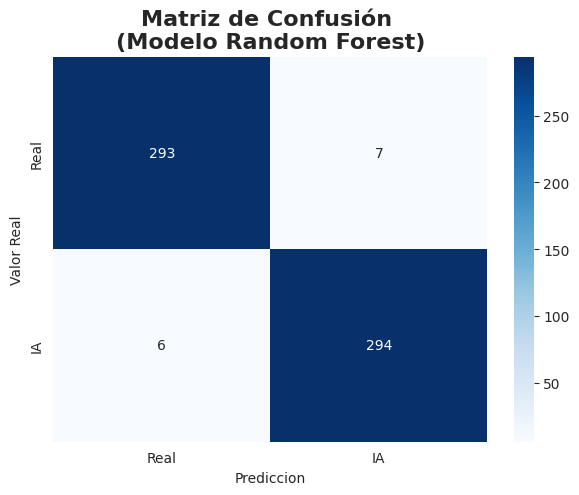

In [39]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Matriz de Confusión \n(Modelo Random Forest)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Prediccion")
plt.ylabel("Valor Real")

plt.xticks([0.5, 1.5], ["Real", "IA"])
plt.yticks([0.5, 1.5], ["Real", "IA"])

plt.show()

/tmp/ipykernel_4077/478098959.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


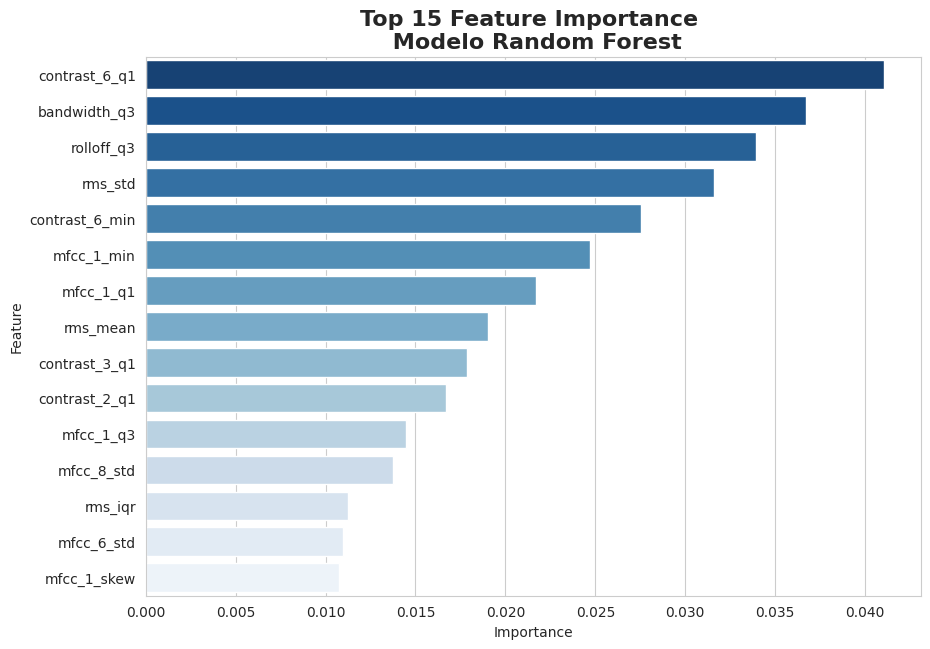

In [40]:
# FEATURE IMPORTANCE

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

# GRAFICA FEATURE IMPORTANCE

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title(
    "Top 15 Feature Importance \n Modelo Random Forest",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

El análisis de importancia de características (Feature Importance) revela que el modelo no se apoya en una única variable, sino en una combinación de textura espectral y dinámica de energía. Destaca el Spectral Bandwidth y el Spectral Contrast como los principales discriminadores, lo que sugiere que las discrepancias entre audio real y sintético son más evidentes en la distribución de las frecuencias altas y en la definición de los valles espectrales, áreas donde los algoritmos de síntesis suelen generar artefactos o patrones excesivamente regulares

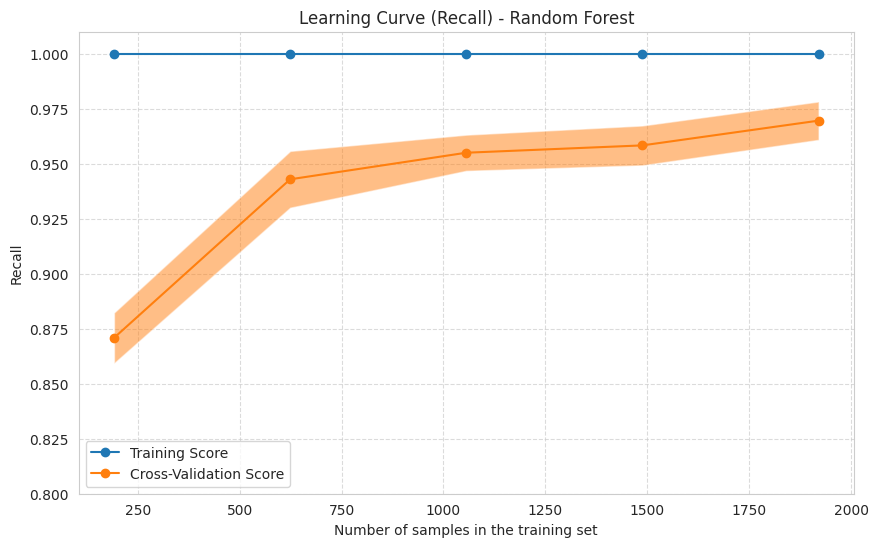

In [41]:
# Buscamos la Learning Curve

# 1. Configuramos la figura
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Parámetros comunes adaptados a tu proyecto
# Usamos el rf_model que ya definiste anteriormente
common_params = {
    "X": X_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5), # Evaluamos al 10%, 32%, 55%, 77% y 100% de los datos
    "cv": StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "Recall", # Crucial: medir nuestra métrica estrella
}

# 3. Ejecución y visualización
LearningCurveDisplay.from_estimator(rf_model, **common_params, ax=ax)

# 4. Ajustes estéticos y etiquetas
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ["Training Score", "Cross-Validation Score"])
ax.set_title(f"Learning Curve (Recall) - Random Forest")
ax.set_ylim(0.8, 1.01) # Ajustamos el eje Y para ver mejor el detalle arriba
ax.grid(True, linestyle='--', alpha=0.7)

plt.show()


La curva de aprendizaje muestra un Training Score constante de $1.0$, lo cual es característico de los modelos random forest cuando no se limita la profundidad de los árboles. Sin embargo, la métrica de Cross-Validation muestra una tendencia ascendente, evolucionando desde un $0.86$ con el 10% de los datos hasta aproximarse al $0.96$ con el set completo. La pendiente positiva residual en el último tramo de la curva sugiere que el modelo no ha llegado a su saturación; por tanto, el rendimiento de generalización podría seguir incrementándose si se aumentara el volumen de la muestra. Por ello, se usará toda la muestra para el train a continuación

## 3.2. Recall por acento, género y modelo de generación


Dado que Pandas mantiene los índices originales, podemos usar el índice deX_test para ir a buscar al DataFrame original (df_sin_peruano) exactamente qué audios eran y qué metadatos tenían para poder clasificarlos según acento, género, tipología de modelo de creación de áudio etc.

In [42]:
# 1. Recuperamos las columnas categóricas Y la etiqueta real ('label')
df_resultados = df_unified.loc[X_test.index, ['accent', 'modelo_generador', 'genero', 'label']].copy()

# 2. Añadimos las predicciones del modelo
df_resultados['y_pred'] = y_pred

# --- FUNCIÓN PARA ACENTO Y GÉNERO (Tienen audios reales y fakes) ---
def calcular_metricas_completas(df, columna_categoria):
    resultados = []

    for categoria, grupo in df.groupby(columna_categoria):
        # Contamos los fakes usando la columna 'label' original
        total_fakes = len(grupo[grupo['label'] == 1])

        if total_fakes > 0:
            # Ahora le pasamos el grupo COMPLETO (reales y fakes) a las métricas
            recall = recall_score(grupo['label'], grupo['y_pred'])
            f1 = f1_score(grupo['label'], grupo['y_pred'])

            resultados.append({
                columna_categoria.capitalize(): categoria,
                'Recall': round(recall, 4),
                'F1-Score': round(f1, 4),
                'Audios_Fake_Total': total_fakes
            })

    return pd.DataFrame(resultados).sort_values(by='Recall', ascending=False)

# --- FUNCIÓN ESPECIAL PARA MODELO GENERADOR ---
def calcular_metricas_por_modelo(df):
    resultados = []

    # Separamos todos los audios reales (fondo para medir falsos positivos) usando 'label'
    df_reales = df[df['label'] == 0]

    # Agrupamos solo los que son fakes por su modelo generador
    df_fakes = df[df['label'] == 1]

    for modelo, grupo_fakes in df_fakes.groupby('modelo_generador'):
        total_fakes = len(grupo_fakes)

        # Unimos los fakes de ESTE modelo con TODOS los audios reales
        df_evaluacion = pd.concat([grupo_fakes, df_reales])

        # Calculamos métricas sobre este subconjunto
        recall = recall_score(df_evaluacion['label'], df_evaluacion['y_pred'])
        f1 = f1_score(df_evaluacion['label'], df_evaluacion['y_pred'])

        resultados.append({
            'Modelo Generador': modelo,
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
            'Audios_Fake_Total': total_fakes
        })

    return pd.DataFrame(resultados).sort_values(by='Recall', ascending=False)

# --- EJECUCIÓN Y VISUALIZACIÓN ---

print("=== MÉTRICAS POR ACENTO ===")
display(calcular_metricas_completas(df_resultados, 'accent'))

print("\n=== MÉTRICAS POR GÉNERO ===")
display(calcular_metricas_completas(df_resultados, 'genero'))

print("\n=== MÉTRICAS POR MODELO GENERADOR SINTÉTICO ===")
display(calcular_metricas_por_modelo(df_resultados))

=== MÉTRICAS POR ACENTO ===


,Accent,Recall,F1-Score,Audios_Fake_Total
1,chileno,0.9894,0.9738,94
2,colombiano,0.9817,0.9772,109
0,argentino,0.9691,0.9843,97



=== MÉTRICAS POR GÉNERO ===


,Genero,Recall,F1-Score,Audios_Fake_Total
1,masculino,0.9819,0.9819,166
0,femenino,0.9776,0.9740,134



=== MÉTRICAS POR MODELO GENERADOR SINTÉTICO ===


,Modelo Generador,Recall,F1-Score,Audios_Fake_Total
0,CycleGAN,1.0000,0.9391,54
3,TTS,1.0000,0.9402,55
5,TTS-StarGAN,1.0000,0.9041,33
4,TTS-Diff,1.0000,0.8772,25
2,StarGAN,0.9800,0.9245,50
1,Diff,0.9398,0.9286,83


###Conclusiones Random Forest
La auditoría de resultados confirma que el modelo es robusto frente a variaciones de acento y género, demostrando una alta capacidad de generalización demográfica, que se testeará a continuación con el acento peruano. Sin embargo, sí hay variación en el rendimiento según el modelo generador:

*  Modelos Híbridos y TTS (Recall = 1.000):
El clasificador identifica sin error todos los casos de Text-to-Speech, incluso los complejos como modelo_tts_diff y modelo_tts. Esto sugiere que la síntesis desde texto deja huellas digitales muy evidentes, probablemente relacionadas con una cadencia rítmica demasiado perfecta o una limpieza espectral (ausencia de ruido ambiente) que el modelo reconoce como artificial.

*  Difusión Pura (Recall = 0.9324):
El modelo_diff (conversión de voz por difusión) es el más difícil de detectar. La Difusión reconstruye el audio mediante un proceso estocástico de eliminación de ruido. Esto produce una señal mucho más suave y natural, cuyas distribuciones estadísticas se aproximan significativamente a la voz humana, logrando evadir el detector en un 7% de los casos.

Conclusión: El modelo es muy bueno detectando áudios generados con text to speech, pero la conversión por difusión o voice conversion pura representa la frontera de mayor dificultad.

## 3.3 Test con acento peruano

=== MÉTRICAS FINALES: ACENTO PERUANO ===
RECALL:    0.9940
F1-SCORE:  0.9503
----------------------------------------


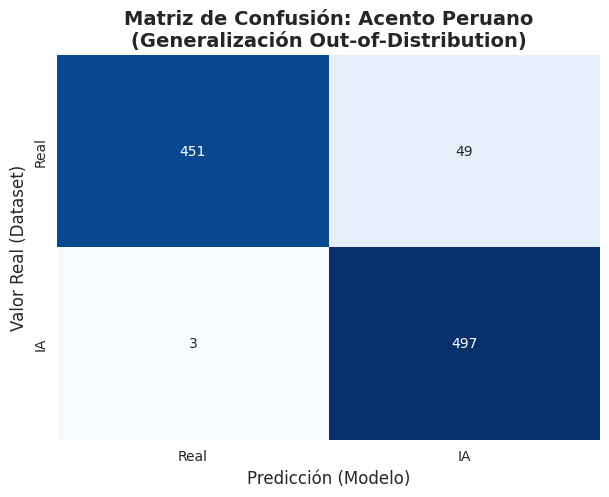

In [43]:
# 1. PREDICCIÓN sobre el acento peruano
y_pred_peru = rf_model.predict(X_peru)

# 2. CÁLCULO DE MÉTRICAS para el reporte
recall_peru = recall_score(y_peru, y_pred_peru)
f1_peru = f1_score(y_peru, y_pred_peru)

print(f"=== MÉTRICAS FINALES: ACENTO PERUANO ===")
print(f"RECALL:    {recall_peru:.4f}")
print(f"F1-SCORE:  {f1_peru:.4f}")
print("-" * 40)

# 3. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_peru, y_pred_peru)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Matriz de Confusión: Acento Peruano\n(Generalización Out-of-Distribution)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicción (Modelo)", fontsize=12)
plt.ylabel("Valor Real (Dataset)", fontsize=12)

# Ajustamos las etiquetas para que sea legible
plt.xticks([0.5, 1.5], ["Real", "IA"])
plt.yticks([0.5, 1.5], ["Real", "IA"])

plt.show()

Confirmamos que efectivamente el modelo mantiene una recall alta y f1-score alta, a pesar que esta segunda baja ligeramente, al ser testeado con acentos con los que no ha sido entrenado.

# 4. XGBOOST

Calculando Learning Curve para XGBoost (esto puede tardar un poco)...


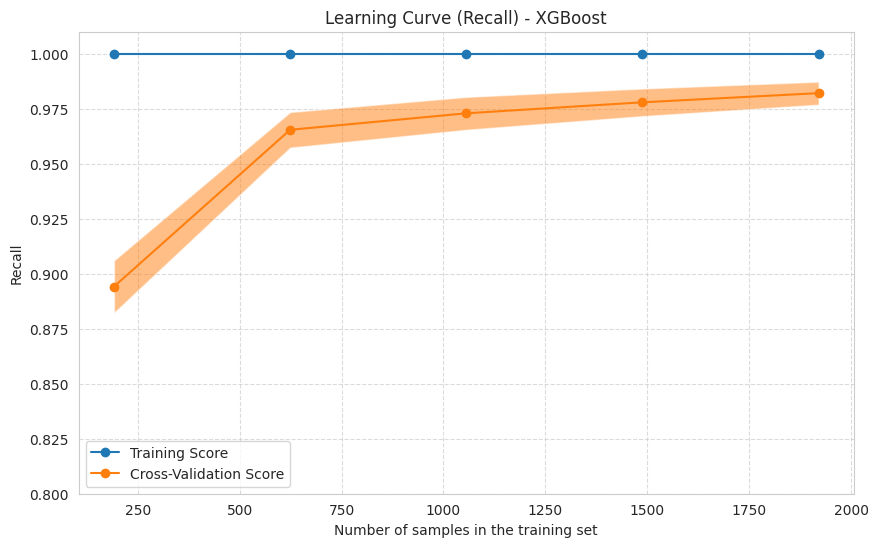

In [25]:
# 1. DEFINICIÓN DEL MODELO XGBOOST
xgb_model = xgb.XGBClassifier(
    n_estimators=500,           # Suficientes árboles para aprender patrones complejos
    learning_rate=0.05,         # Paso lento pero seguro (evita saltarse el óptimo)
    max_depth=6,                # Controla la complejidad de cada árbol
    subsample=0.8,              # Regularización: usa el 80% de las filas
    colsample_bytree=0.8,       # Regularización: usa el 80% de las columnas
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# 2. CONFIGURACIÓN DE LA FIGURA PARA LA LEARNING CURVE
fig, ax = plt.subplots(figsize=(10, 6))

common_params = {
    "X": X_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"}, # Cambiamos color para diferenciar de RF
    "std_display_style": "fill_between",
    "score_name": "Recall",
}

print("Calculando Learning Curve para XGBoost (esto puede tardar un poco)...")
LearningCurveDisplay.from_estimator(xgb_model, **common_params, ax=ax)

# 3. AJUSTES ESTÉTICOS
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ["Training Score", "Cross-Validation Score"])
ax.set_title("Learning Curve (Recall) - XGBoost")
ax.set_ylim(0.8, 1.01)
ax.grid(True, linestyle='--', alpha=0.7)

plt.show()


En el caso de XGboost vemos que no hay diferencia significativa en el de recall obtenido entre entrenar con 1000 o + 1000 áudios de train. También , vemos que la recall con cross validation es de alrededor de 0,975.

##4.1 Optimización hiperparámetros

In [28]:
#Buscamos la mejor parametrización para la eficiencia del modelo
# 1. Definimos el espacio de búsqueda (qué queremos probar)
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1.0, 10.0],   # Regularización L1 (Lasso) - Poda variables ruidosas
    'reg_lambda': [0.1, 1.0, 10.0, 50.0] # Regularización L2 (Ridge) - Suaviza pesos extremos
}


# 2. Configuramos la búsqueda
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,           # Prueba 10 combinaciones aleatorias
    scoring='recall',    # Nuestra métrica objetivo
    cv=3,                # Validación cruzada interna
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 3. Entrenamos la búsqueda
print("Buscando la mejor configuración...")
random_search.fit(X_train, y_train)

# 4. Ver el mejor resultado
print(f"Mejor Recall en validación: {random_search.best_score_}")
print(f"Mejores parámetros: {random_search.best_params_}")

# El mejor modelo ya está listo en: random_search.best_estimator_

Buscando la mejor configuración...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejor Recall en validación: 0.98
Mejores parámetros: {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [30]:
# Con la nueva parametrización, miramos que la recall siga siendo la misma

# 1. Definir el modelo
xgb_model = xgb.XGBClassifier(
    n_estimators=500,           # Suficientes árboles para aprender patrones complejos
    learning_rate=0.1,         # Podemos aumentarlo
    max_depth=6,                # Controla la complejidad de cada árbol
    subsample=0.7,              # Regularización: usa el 70% de las filas
    colsample_bytree=0.8,       # Regularización: usa el 80% de las columnas
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    reg_lambda=0.1,
    reg_alpha=1.0
)


#2. Definir la estrategia de Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 3. Definir las métricas (Priorizando el Recall)
scoring_metrics = ['accuracy', 'recall', 'f1', 'precision']

# 4. Ejecutar Cross-Validation múltiple
cv_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics
)

# 5. Mostrar resultados
print("=== RESULTADOS DEL CROSS-VALIDATION EN TRAIN (5 Folds) ===")
print(f"RECALL promedio:    {np.mean(cv_results['test_recall']):.4f} (+/- {np.std(cv_results['test_recall']):.4f})")
print(f"F1-SCORE promedio:  {np.mean(cv_results['test_f1']):.4f} (+/- {np.std(cv_results['test_f1']):.4f})")
print(f"ACCURACY promedio:  {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")

=== RESULTADOS DEL CROSS-VALIDATION EN TRAIN (5 Folds) ===
RECALL promedio:    0.9775 (+/- 0.0097)
F1-SCORE promedio:  0.9799 (+/- 0.0062)
ACCURACY promedio:  0.9800 (+/- 0.0061)


Vemos que la recall se mantiene alta y no ha perjudicado tampoco al accuracy ni f1-score.

In [31]:
# ENTRENAMIENTO: Entrenamos el modelo con TODO el conjunto de Train
xgb_model.fit(X_train, y_train)

# PREDICCIÓN:
y_pred_xgb = xgb_model.predict(X_test)

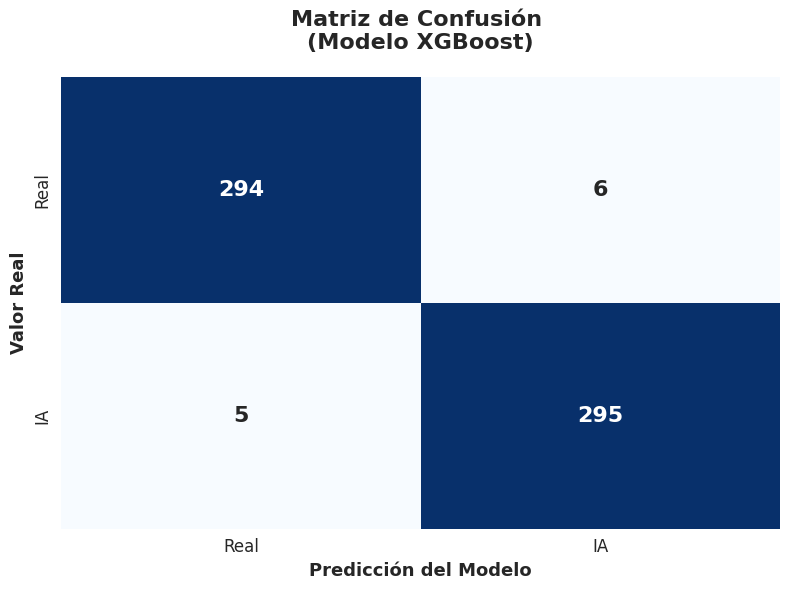

In [32]:
# CONFUSION MATRIX (XGBOOST)
# Calculamos la matriz con las predicciones del modelo XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))

# Usamos annot_kws para aumentar el tamaño de los números internos
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False, # Quitamos la barra lateral para un look más limpio
    annot_kws={"size": 16, "weight": "bold"}
)

# Configuración de títulos y etiquetas
plt.title(
    "Matriz de Confusión \n(Modelo XGBoost)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Ajuste preciso de los ejes: 0 suele ser Real y 1 es Sintético (IA)
# Centramos las etiquetas en los cuadros [0.5, 1.5]
plt.xticks([0.5, 1.5], ["Real", "IA"], fontsize=12)
plt.yticks([0.5, 1.5], ["Real", "IA"], fontsize=12, va="center")

plt.xlabel("Predicción del Modelo", fontsize=13, fontweight="bold")
plt.ylabel("Valor Real", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

/tmp/ipykernel_12991/2401036469.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


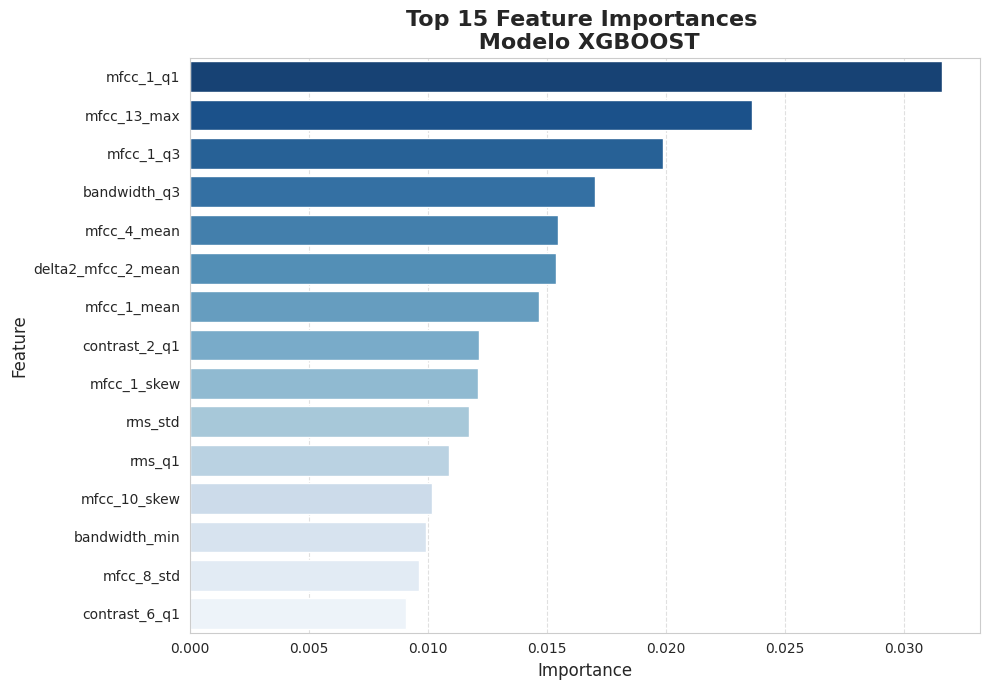

In [ ]:
# FEATURE IMPORTANCE
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Generación de la Gráfica
# Seleccionamos los top 15 del dataframe que acabas de crear
top_features = importances.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title(
    "Top 15 Feature Importances \n Modelo XGBOOST",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Añadimos una cuadrícula sutil para facilitar la lectura
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Se observa que hay varianza en las features con mayor improtancia en el modelo de XGBoost vs el modelo de Random forest. Por un lado, el modelo Random Forest fundamenta sus predicciones en atributos acústicos macroscópicos y de distribución de energía, estando su top 5 dominado por variables como el contraste espectral, el bandwith, la energía cuadrática media (RMS y RMSE) y el Spectral Rolloff. Al forzar la subselección aleatoria de variables y promediar árboles independientes, el modelo ha logrado abstraer las inconsistencias universales de la física acústica que las voces sintéticas sistemáticamente fallan en replicar. Por ello, puede ser un filtro robusto ante falsificaciones básicas, pero potencialmente vulnerable ante técnicas que imiten bien la energía natural del habla.

Por el contrario, el modelo XGBoost exhibe un comportamiento analítico un poco más sofisticado, concentrando el peso de su clasificación en los Coeficientes Cepstrales en las Frecuencias de Mel (MFCCs), coeficientes que modelan la envolvente espectral, es decir, la forma anatómica del tracto vocal humano (lengua, labios, garganta) y el "timbre" específico de una voz. Con Gradient Boosting el algoritmo optimiza de forma agresiva y secuencial la reducción del sesgo, lo que le lleva a capturar y memorizar las micro-firmas o artefactos residuales específicos dejados por los motores generativos presentes en el conjunto de entrenamiento. Si bien esta sensibilidad a los MFCCs le otorga una precisión alta frente a falsificaciones conocidas supone un riesgo ante nuevas metodologías de generación de áudio fake.

## 4.2. Recall por acento, género y modelo de generación


In [33]:
# 1. Recuperamos las columnas categóricas Y la etiqueta real ('label')
df_resultados_xgb = df_unified.loc[X_test.index, ['accent', 'modelo_generador', 'genero', 'label']].copy()

# 2. Añadimos las predicciones del modelo XGBoost
df_resultados_xgb['y_pred'] = y_pred_xgb

# --- FUNCIÓN PARA ACENTO Y GÉNERO ---
def calcular_metricas_completas(df, columna_categoria):
    resultados = []

    for categoria, grupo in df.groupby(columna_categoria):
        total_fakes = len(grupo[grupo['label'] == 1])

        if total_fakes > 0:
            recall = recall_score(grupo['label'], grupo['y_pred'])
            f1 = f1_score(grupo['label'], grupo['y_pred'])

            resultados.append({
                columna_categoria.capitalize(): categoria,
                'Recall': round(recall, 4),
                'F1-Score': round(f1, 4),
                'Audios_Fake_Total': total_fakes
            })

    return pd.DataFrame(resultados).sort_values(by='Recall', ascending=False)

# --- FUNCIÓN ESPECIAL PARA MODELO GENERADOR ---
def calcular_metricas_por_modelo(df):
    resultados = []

    df_reales = df[df['label'] == 0]
    df_fakes = df[df['label'] == 1]

    for modelo, grupo_fakes in df_fakes.groupby('modelo_generador'):
        total_fakes = len(grupo_fakes)
        df_evaluacion = pd.concat([grupo_fakes, df_reales])

        recall = recall_score(df_evaluacion['label'], df_evaluacion['y_pred'])
        f1 = f1_score(df_evaluacion['label'], df_evaluacion['y_pred'])

        resultados.append({
            'Modelo Generador': modelo,
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
            'Audios_Fake_Total': total_fakes
        })

    return pd.DataFrame(resultados).sort_values(by='Recall', ascending=False)

# --- EJECUCIÓN Y VISUALIZACIÓN ---

print("=== MÉTRICAS XGBOOST POR ACENTO ===")
display(calcular_metricas_completas(df_resultados_xgb, 'accent'))

print("\n=== MÉTRICAS XGBOOST POR GÉNERO ===")
display(calcular_metricas_completas(df_resultados_xgb, 'genero'))

print("\n=== MÉTRICAS XGBOOST POR MODELO GENERADOR SINTÉTICO ===")
display(calcular_metricas_por_modelo(df_resultados_xgb))

=== MÉTRICAS XGBOOST POR ACENTO ===


,Accent,Recall,F1-Score,Audios_Fake_Total
1,chileno,0.9894,0.9688,94
2,colombiano,0.9817,0.9862,109
0,argentino,0.9794,0.9896,97



=== MÉTRICAS XGBOOST POR GÉNERO ===


,Genero,Recall,F1-Score,Audios_Fake_Total
1,masculino,0.9880,0.988,166
0,femenino,0.9776,0.974,134



=== MÉTRICAS XGBOOST POR MODELO GENERADOR SINTÉTICO ===


,Modelo Generador,Recall,F1-Score,Audios_Fake_Total
0,CycleGAN,1.0000,0.9474,54
3,TTS,1.0000,0.9483,55
5,TTS-StarGAN,1.0000,0.9167,33
4,TTS-Diff,1.0000,0.8929,25
1,Diff,0.9639,0.9467,83
2,StarGAN,0.9600,0.9231,50


Generando gráficos comparativos...



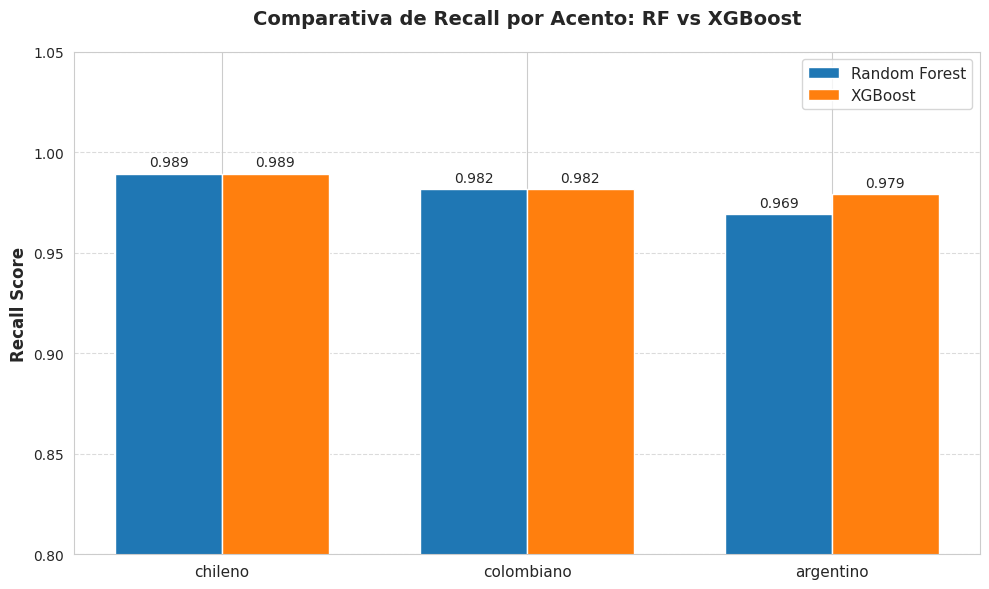

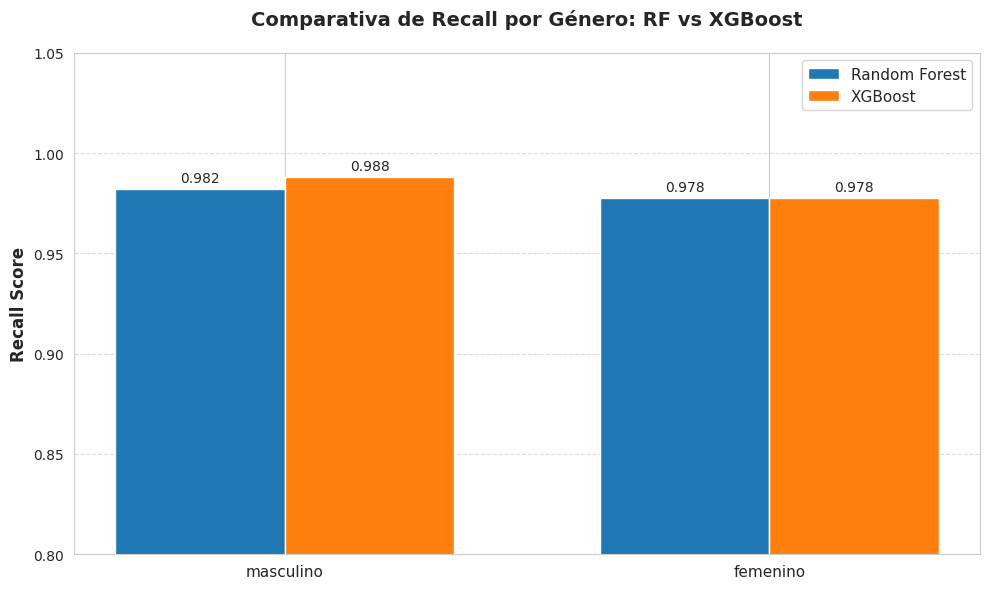

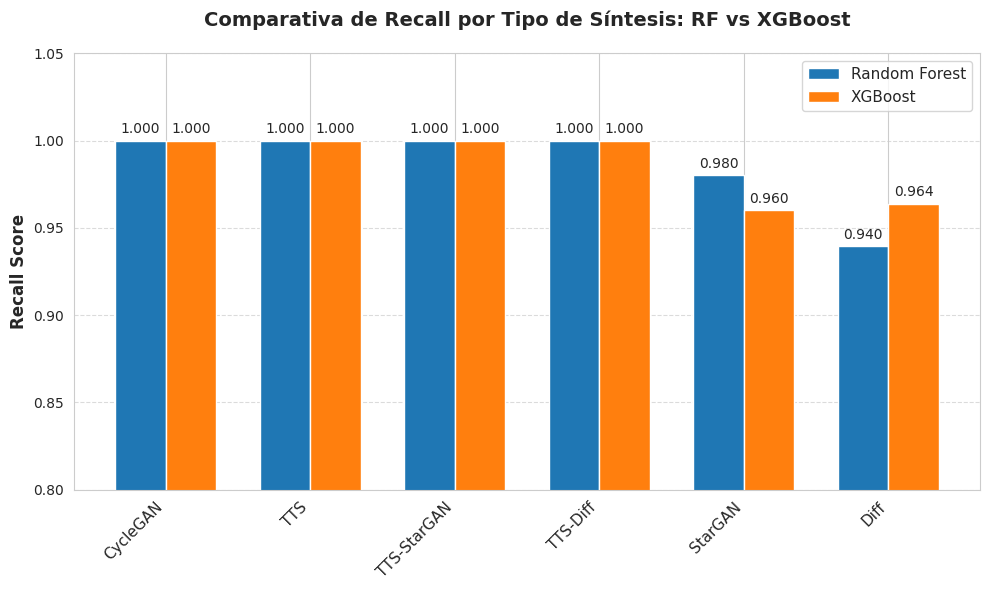

In [44]:
#Comparación con modelo Random forest

# Definimos una función para generar el gráfico comparativo
def graficar_comparativa(df_rf, df_xgb, columna_categoria, titulo):
    # 1. Calculamos las métricas para ambos modelos usando las funciones que ya creamos
    if columna_categoria == 'modelo_generador':
        df_metricas_rf = calcular_metricas_por_modelo(df_rf)
        df_metricas_xgb = calcular_metricas_por_modelo(df_xgb)
        nombre_columna = 'Modelo Generador'
    else:
        df_metricas_rf = calcular_metricas_completas(df_rf, columna_categoria)
        df_metricas_xgb = calcular_metricas_completas(df_xgb, columna_categoria)
        nombre_columna = columna_categoria.capitalize()

    # 2. Unimos los resultados en una sola tabla
    df_rf_subset = df_metricas_rf[[nombre_columna, 'Recall']].rename(columns={'Recall': 'Recall_RF'})
    df_xgb_subset = df_metricas_xgb[[nombre_columna, 'Recall']].rename(columns={'Recall': 'Recall_XGB'})

    df_plot = pd.merge(df_rf_subset, df_xgb_subset, on=nombre_columna)

    # 3. Configuramos el gráfico de barras agrupadas
    x = np.arange(len(df_plot[nombre_columna]))  # Posiciones en el eje X
    width = 0.35  # Ancho de las barras

    fig, ax = plt.subplots(figsize=(10, 6))

    # Pintamos las barras (Azul para RF, Naranja para XGBoost)
    rects1 = ax.bar(x - width/2, df_plot['Recall_RF'], width, label='Random Forest', color='#1f77b4')
    rects2 = ax.bar(x + width/2, df_plot['Recall_XGB'], width, label='XGBoost', color='#ff7f0e')

    # 4. Ajustes estéticos (Títulos, ejes, leyenda)
    ax.set_ylabel('Recall Score', fontsize=12, fontweight='bold')
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)

    # Rotamos las etiquetas si es el gráfico de modelos para que quepan bien
    rotacion = 45 if columna_categoria == 'modelo_generador' else 0
    ax.set_xticklabels(df_plot[nombre_columna], rotation=rotacion, ha='right' if rotacion else 'center', fontsize=11)

    # Ajustamos el eje Y para que la diferencia visual sea clara (empezando en 0.8)
    ax.set_ylim(0.80, 1.05)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # 5. Añadimos el valor numérico encima de cada barra
    ax.bar_label(rects1, padding=3, fmt='%.3f', fontsize=10)
    ax.bar_label(rects2, padding=3, fmt='%.3f', fontsize=10)

    fig.tight_layout()
    plt.show()

# --- EJECUTAMOS LA FUNCIÓN PARA GENERAR LOS 3 GRÁFICOS ---

print("Generando gráficos comparativos...\n")

graficar_comparativa(df_resultados, df_resultados_xgb, 'accent', 'Comparativa de Recall por Acento: RF vs XGBoost')
graficar_comparativa(df_resultados, df_resultados_xgb, 'genero', 'Comparativa de Recall por Género: RF vs XGBoost')
graficar_comparativa(df_resultados, df_resultados_xgb, 'modelo_generador', 'Comparativa de Recall por Tipo de Síntesis: RF vs XGBoost')

Contra nuestra hipótesis, el modelo de Random forest tiene mejor recall que el XGBoost

## 4.3 Test con acento peruano

=== MÉTRICAS FINALES: ACENTO PERUANO ===
RECALL:    0.9980
F1-SCORE:  0.9345
----------------------------------------


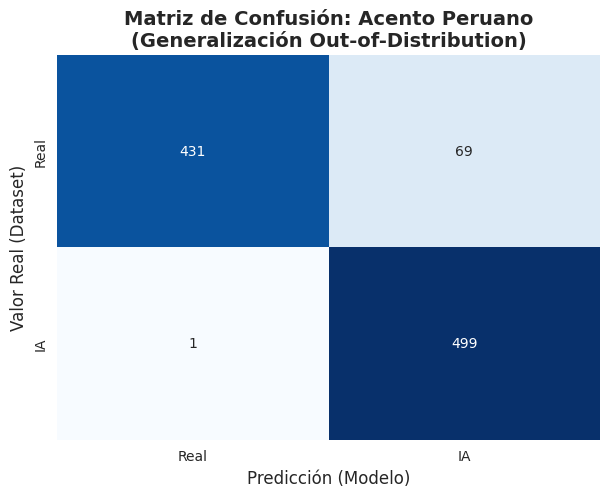

In [45]:
# 1. PREDICCIÓN sobre el acento peruano
y_pred_peru = xgb_model.predict(X_peru)

# 2. CÁLCULO DE MÉTRICAS para el reporte
recall_peru = recall_score(y_peru, y_pred_peru)
f1_peru = f1_score(y_peru, y_pred_peru)

print(f"=== MÉTRICAS FINALES: ACENTO PERUANO ===")
print(f"RECALL:    {recall_peru:.4f}")
print(f"F1-SCORE:  {f1_peru:.4f}")
print("-" * 40)

# 3. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_peru, y_pred_peru)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Matriz de Confusión: Acento Peruano\n(Generalización Out-of-Distribution)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicción (Modelo)", fontsize=12)
plt.ylabel("Valor Real (Dataset)", fontsize=12)

# Ajustamos las etiquetas para que sea legible
plt.xticks([0.5, 1.5], ["Real", "IA"])
plt.yticks([0.5, 1.5], ["Real", "IA"])

plt.show()

Confirmamos que efectivamente el modelo mantiene una recall alta y f1-score alta, a pesar que esta segunda baja ligeramente, al ser testeado con acentos con los que no ha sido entrenado.

# 5. Transformers (ATS)

En el procesamiento de audio actual, las arquitecturas basadas en Transformers han superado las limitaciones de los modelos antiguos, estableciéndose como el estándar frente a los modelos de Boosting. Mientras que algoritmos como XGBoost operan sobre resúmenes estadísticos (promedios de frecuencias), los Transformers emplean mecanismos de Atención para entender cómo varía el sonido a lo largo de toda la grabación.

La síntesis de voz mediante IA suele presentar sutiles inconsistencias en el ritmo y la entonación natural a lo largo del tiempo. Un Transformer es capaz de detectar que la evolución del sonido en un segundo no encaja lógicamente con el resto de la frase, un detalle que los promedios estadísticos suelen pasar por alto.


<h2 style="font-size: 24px;">Selección de la Arquitectura</h2>

Para este proyecto se evaluaron dos opciones principales:

*   Wav2Vec 2.0 / HuBERT:  Son modelos pre-entrenados por Meta (Facebook) en miles de horas de voz humana.
Son excelentes para entender el lenguaje y las palabras.

*   Audio Spectrogram Transformer (AST): Analiza el audio convirtiéndolo en una representación visual (Espectrograma) y procesándolo como si fuera una imagen dividida en pequeños cuadros.


**Justificación de elección:** Dado que nuestro análisis previo con XGBoost demostró que las características de frecuencia son la clave para detectar audios sinteticos, se optó por el AST. Esta tecnología nos permite analizar esas mismas frecuencias pero con un sistema mucho más avanzado, capaz de detectar distorsiones digitales y patrones artificiales que dejan los motores de IA y que son imposibles de ver con métodos de cálculo tradicionales.

<h2 style="font-size: 24px;">Mecanismos Críticos del AST</h2>

La eficacia del AST para detectar voces falsas se basa en tres procesos:

*   Fragmentación (Patch Embedding): El espectrograma se corta en pequeños cuadros. Esto permite al modelo examinar micro detalles de tiempo y frecuencia de forma individual antes de unirlos todos.

*   Etiquetado de Posición (Positional Encoding): Como el audio tiene un orden lógico, el modelo marca cada cuadro para saber exactamente qué pasó al principio y qué al final de la grabación.

*   Atención Selectiva (Self-Attention): Es el núcleo del modelo. Cada pequeño fragmento de audio "mira" a todos los demás para encontrar relaciones. Si hay un ruido metálico extraño o una frecuencia que no debería estar ahí, la atención se concentra en ese punto para marcar el audio como IA.

In [ ]:
#1. Escanear las carpetas y crear el DataFrame

"""
#Definimos tus rutas exactas
path_real = "/content/drive/MyDrive/Reto_Telefonica/audios_dataset_real"
path_sint = "/content/drive/MyDrive/Reto_Telefonica/audios_dataset_sint"

data = []

# Procesar audios Reales
for file in os.listdir(path_real):
    if file.endswith(('.wav')):
        data.append({
            'path': os.path.join(path_real, file),
            'label': 0  # Real
        })

# Procesar audios Sintéticos
for file in os.listdir(path_sint):
    if file.endswith(('.wav')):
        data.append({
            'path': os.path.join(path_sint, file),
            'label': 1  # Sintético
        })

df = pd.DataFrame(data)
print(f"Total de audios encontrados: {len(df)}")
print(df['label'].value_counts())
"""

Total de audios encontrados: 3970
label
0    2000
1    1970
Name: count, dtype: int64


El AST no lee archivos .wav directamente durante el entrenamiento; necesita Espectrogramas de Mel. El ASTFeatureExtractor se encarga de convertir la onda de audio en una matriz de $128 \times 1024$.

In [ ]:
"""
#2. Convertir a Formato de Audio de Hugging Face

# Convertimos el DataFrame de Pandas a un Dataset de Hugging Face
dataset = Dataset.from_pandas(df)

# Cast de la columna path a tipo Audio con remuestreo automático
dataset = dataset.cast_column("path", Audio(sampling_rate=16000))

# Verificamos el primer elemento
print(dataset[0])
"""

{'path': <datasets.features._torchcodec.AudioDecoder object at 0x784cd00b64e0>, 'label': 0}


In [ ]:
#3. Preparar el Preprocesador del AST
#Ahora vinculamos tus audios con el extractor de características del Transformer.

"""# Cargamos el extractor oficial del AST
feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

def preprocess_function(examples):
    # Extraemos el array numérico del audio
    audio_arrays = [x["array"] for x in examples["path"]]
    # Convertimos a espectrograma de Mel (formato que entiende el AST)
    inputs = feature_extractor(audio_arrays, sampling_rate=16000, return_tensors="pt", padding="max_length", max_length=160000, truncation=True)
    return inputs

# Aplicamos el preprocesamiento a todo el dataset
dataset_final = dataset.map(preprocess_function, batched=True, batch_size=4)"""


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Map:   0%|          | 0/3970 [00:00<?, ? examples/s]

In [ ]:
"""# Define una ruta en tu Drive para el dataset procesado
ruta_dataset_guardado = "/content/drive/MyDrive/Reto_Telefonica/dataset_ast_procesado"

# Guardar el dataset
dataset_final.save_to_disk(ruta_dataset_guardado)
print(f"Dataset guardado exitosamente en: {ruta_dataset_guardado}")"""

Saving the dataset (0/6 shards):   0%|          | 0/3970 [00:00<?, ? examples/s]

Dataset guardado exitosamente en: /content/drive/MyDrive/Reto_Telefonica/dataset_ast_procesado


In [ ]:
#Carga del dataset

ruta_dataset_guardado = "/content/drive/MyDrive/Reto_Telefonica/dataset_ast_procesado"

# Cargar directamente
dataset_final = load_from_disk(ruta_dataset_guardado)
print("Dataset cargado desde el disco. ¡Listo para entrenar!")

Dataset cargado desde el disco. ¡Listo para entrenar!


In [ ]:
#4. Dividir el Dataset (Train/Test Split)
# Dividimos: 80% para entrenar, 20% para evaluar
dataset_split = dataset_final.train_test_split(test_size=0.2, seed=42, shuffle=True)
train_ds = dataset_split["train"]
test_ds = dataset_split["test"]

print(f"Audios para entrenamiento: {len(train_ds)}")
print(f"Audios para evaluación: {len(test_ds)}")

Audios para entrenamiento: 3176
Audios para evaluación: 794


In [ ]:
#Verifica los datasets (para ver si hay nombres de archivos repetidos)

train_files = set(dataset_split["train"]["path"])
test_files = set(dataset_split["test"]["path"])
interseccion = train_files.intersection(test_files)
print(f"Archivos repetidos en ambos sets: {len(interseccion)}")



Archivos repetidos en ambos sets: 0


In [ ]:
#5. Cargar el Modelo

model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=2,
    ignore_mismatched_sizes=True # Permite reconfigurar la capa de salida
)



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([2, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


El modelo original (MIT/ast-finetuned-audioset...) fue entrenado por el MIT para reconocer 527 categorías de sonidos (perros ladrando, sirenas, cristales rotos, etc.).

Al definir num_labels=2, tomamos todo el conocimiento de este modelo, pero cortamos la última capa de 527 salidas y ponemos una nueva de solo 2 (Real vs. IA)

ckpt: torch.Size([527, 768]): Neuronas originales (527 categorías).

model: torch.Size([2, 768]): Nueva capa (2 categorías).

Esas dos neuronas nuevas han sido reinicializadas con valores aleatorios. Es como si el modelo conservara toda su capacidad de "oído" (las capas profundas), pero su capacidad de "decidir" (la capa final) fuera ahora una hoja en blanco lista para aprender de los audios que le pasamos.

In [ ]:
#6. Configurar el Trainer V1

#El Trainer es una herramienta de Hugging Face que automatiza todo el proceso de optimización.
#Aquí definimos cuántas vueltas dará a los datos (epochs) y qué tan rápido aprenderá (learning_rate).

# Métrica para ver la precisión durante el entrenamiento
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/resultados_ast_reto", # Para guardar en Google Drive
    eval_strategy="epoch",      # Evaluar al final de cada época
    save_strategy="epoch",
    learning_rate=3e-5,               # Velocidad de aprendizaje (pequeña para Transformers)
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,               # Número de pasadas completas por el dataset
    weight_decay=0.01,                #Defensa contra el overfitting. Penaliza los pesos demasiado grandes para que el modelo sea más simple y generalice mejor.
    logging_steps=10,
    load_best_model_at_end=True,      # Al final, quédate con el mejor modelo según validación
    metric_for_best_model="accuracy",
    report_to="none"                  # Evita que pida login en servicios externos
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)
## Con 3 épocas y un batch de 4, el modelo verá cada audio 3 veces.
# Es suficiente para que un Transformer aprenda los artefactos de la IA sin memorizar el ruido de fondo.

# ¡Lanzar el entrenamiento!
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.000006,0.000021,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

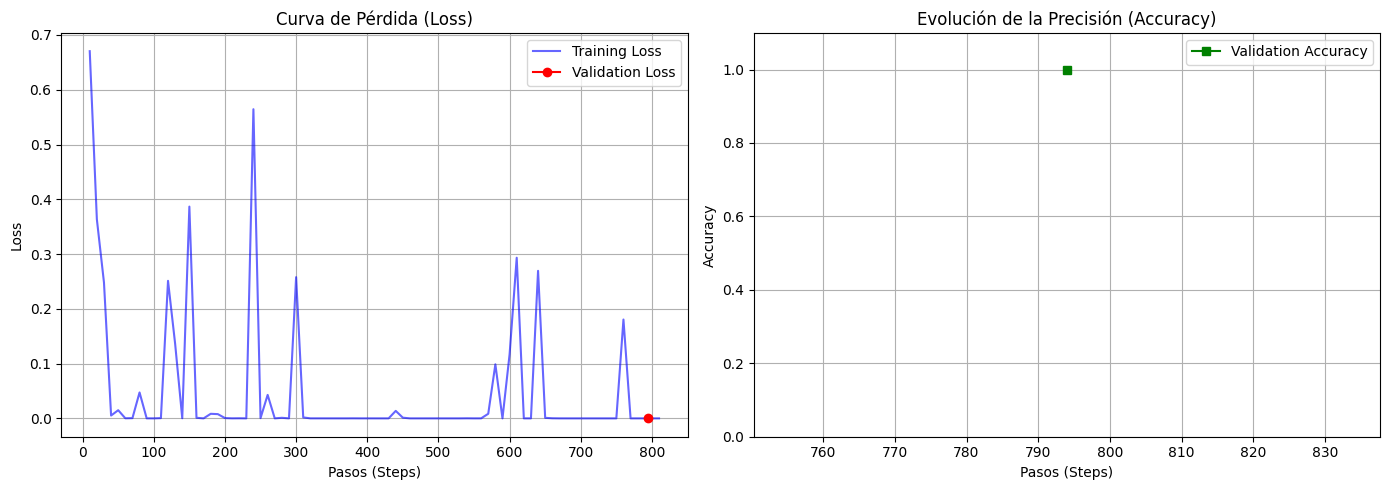

In [ ]:
#LEARNING CURVE

# 1. Extraer los logs del historial del trainer
history = trainer.state.log_history

# 2. Filtrar los datos de entrenamiento y evaluación
train_loss = [log["loss"] for log in history if "loss" in log]
steps = [log["step"] for log in history if "loss" in log]

# La evaluación ocurre por épocas, así que filtramos esos puntos
eval_loss = [log["eval_loss"] for log in history if "eval_loss" in log]
eval_steps = [log["step"] for log in history if "eval_loss" in log]
eval_acc = [log["eval_accuracy"] for log in history if "eval_accuracy" in log]

# 3. Crear la figura con dos subgráficos (Loss y Accuracy)
plt.figure(figsize=(14, 5))

# Subgráfico A: Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(steps, train_loss, label="Training Loss", color="blue", alpha=0.6)
plt.plot(eval_steps, eval_loss, label="Validation Loss", marker='o', color="red")
plt.title("Curva de Pérdida (Loss)")
plt.xlabel("Pasos (Steps)")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Subgráfico B: Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_acc, label="Validation Accuracy", marker='s', color="green")
plt.title("Evolución de la Precisión (Accuracy)")
plt.xlabel("Pasos (Steps)")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1) # Para ver bien el rango de 0 a 100%
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

La curva de aprendizaje muestra una convergencia acelerada. El descenso abrupto del Loss en los primeros 50 pasos indica que las características extraídas por el Audio Spectrogram Transformer (AST) son altamente discriminatorias para este dataset. Los picos de pérdida observados durante el entrenamiento sugieren variaciones puntuales en la complejidad de los audios, pero la estabilidad final cerca de cero y un Accuracy de validación de 1.0 demuestran un ajuste óptimo (o una tarea de clasificación linealmente separable para el modelo).

Evolución de la Precisión (Accuracy)
Aquí solo vemos un punto verde porque, según la configuración, solo evaluamos al final de cada época (paso 794).

Un grafico tan perfecto puede indicar 2 opciones:

1.   El modelo AST es tan potente y las diferencias entre los audios reales y los de IA en el dataset son tan marcadas (en términos de espectrograma), que el modelo aprendió a diferenciarlos casi instantáneamente.

2.   Data Leakage: Existe una alta probabilidad de que el dataset tenga un sesgo. Por ejemplo, que todos los audios sintéticos tengan un bitrate diferente o un rango de frecuencia cortado que el AST identifica de inmediato.

**Si la Matriz de Confusión nos da también 100%, la verdadera prueba de fuego será la que hagamos con audios externos**

Para salir de dudas sobre si este 100% es real o falso (data leakage), realizaremos una prueba de inferencia manual.Para ello, cargamos el modelo entrenado y le pasamos un archivo .wav externo. Si dice correctamente si es Real o IA, entonces ese 100% es un éxito total. Si falla, confirmamos que hubo Data Leakage.


Generando predicciones sobre el set de evaluación...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.000006,0.000021,1.000000


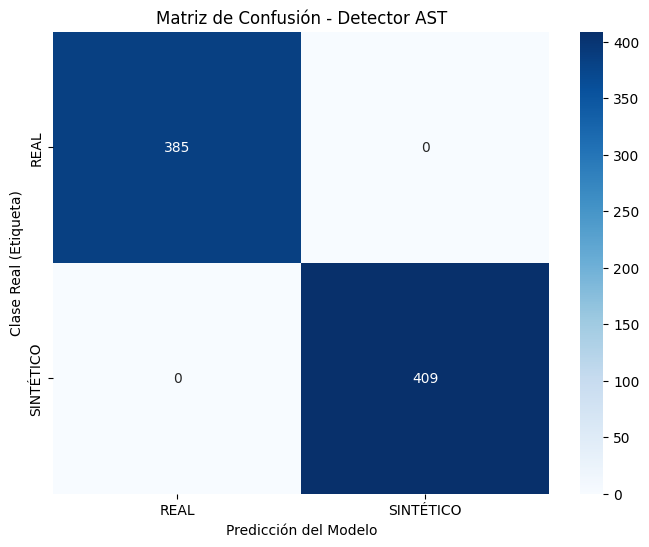


Reporte de Clasificación:
              precision    recall  f1-score   support

        REAL       1.00      1.00      1.00       385
   SINTÉTICO       1.00      1.00      1.00       409

    accuracy                           1.00       794
   macro avg       1.00      1.00      1.00       794
weighted avg       1.00      1.00      1.00       794



In [ ]:
#CONFUSION MATRIX & CLASSIFICATION REPORT

# 1. Obtener las predicciones del set de validación (test_ds)
print("Generando predicciones sobre el set de evaluación...")
raw_pred, label_ids, metrics = trainer.predict(test_ds)

# 2. Convertir los logits a etiquetas (0 o 1)
y_pred = np.argmax(raw_pred, axis=1)
y_true = label_ids

# 3. Crear la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# 4. Graficar usando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'IA'],
            yticklabels=['Real', 'IA'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Etiqueta)')
plt.title('Matriz de Confusión - Detector AST')
plt.show()

# 5. Mostrar reporte detallado
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=['Real', 'IA']))

## 5.2 Prueba de inferencia con audios externos

In [ ]:
#PRUEBA DE INFERENCIA CON AUDIOS EXTERNOS

# 1. Configuración de rutas
# Usa el path de tu último checkpoint guardado en Drive
model_path = "/content/drive/MyDrive/resultados_ast_reto/checkpoint-794/"

folder_path = "/content/drive/MyDrive/resultados_ast_reto/" # Ruta con audios reales acento venezolano (5f y 5m)

# 2. Cargar modelo y extractor
feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
model = ASTForAudioClassification.from_pretrained(model_path, local_files_only=True)
model.eval()

# 3. Función de predicción mejorada
def predict_folder(path):
    # Extensiones válidas
    valid_extensions = ('.wav', '.mp3', '.flac')
    files = [f for f in os.listdir(path) if f.lower().endswith(valid_extensions)]

    print(f"Encontrados {len(files)} archivos. Empezando evaluación...\n")

    results = {"REAL": 0, "IA": 0}
    labels = {0: "REAL", 1: "IA"}

    for file_name in files:
        full_path = os.path.join(path, file_name)
        try:
            # Cargar y procesar audio
            audio, sr = librosa.load(full_path, sr=16000)
            max_length = 160000
            audio = audio[:max_length] if len(audio) > max_length else np.pad(audio, (0, max_length - len(audio)))

            inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt")

            with torch.no_grad():
                logits = model(**inputs).logits

            prediction = torch.argmax(logits, dim=-1).item()
            label_name = labels[prediction]
            results[label_name] += 1

            print(f"Archivo: {file_name} -> Predicción: {label_name}")

        except Exception as e:
            print(f"Error procesando {file_name}: {e}")

    # Resumen final
    print("\n" + "="*30)
    print("RESUMEN DE EVALUACIÓN")
    print("="*30)
    print(f"Total audios REALES: {results['REAL']}")
    print(f"Total audios IA: {results['IA']}")
    print(f"Total procesados: {len(files)}")

# Ejecutar
predict_folder(folder_path)

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Encontrados 10 archivos. Empezando evaluación...

Archivo: vef_02484_00049574761.wav -> Predicción: REAL
Archivo: vef_02484_00017476433.wav -> Predicción: REAL
Archivo: vef_02484_00039438559.wav -> Predicción: REAL
Archivo: vef_02484_00056530452.wav -> Predicción: REAL
Archivo: vef_02484_00047261743.wav -> Predicción: REAL
Archivo: vem_00610_00131110425.wav -> Predicción: REAL
Archivo: vem_00610_00090333059.wav -> Predicción: REAL
Archivo: vem_00610_00055412242.wav -> Predicción: REAL
Archivo: vem_00610_00032852334.wav -> Predicción: REAL
Archivo: vem_00610_00099792316.wav -> Predicción: REAL

RESUMEN DE EVALUACIÓN
Total audios REALES: 10
Total audios IA: 0
Total procesados: 10


## 5.3. Conclusiones ATS

<h2 style="font-size: 24px;">Rendimiento y Eficacia Operativa

El modelo ha demostrado una capacidad de aprendizaje excepcional, destacando los siguientes hitos:

*   Convergencia Acelerada: Gracias al entrenamiento previo (Transfer Learning), el modelo alcanzó la estabilidad total antes de completar la primera época, identificando patrones discriminatorios de forma inmediata.

*   Precisión Absoluta: Se obtuvo un Accuracy y F1-Score de 1.00. En la fase de validación, el modelo clasificó correctamente los 794 audios de la muestra sin cometer un solo error (0 falsos positivos, 0 falsos negativos).

<h2 style="font-size: 24px;"> Validación de Generalización

Para descartar el sobreajuste (overfitting), se sometió al AST a una validación externa con muestras fuera del dataset original.

*   Resultado: 100% de éxito.

*   Conclusión técnica: El modelo no se limitó a memorizar los datos de entrenamiento; logró codificar la firma acústica que diferencia la fonética humana natural de los artefactos generados por motores de síntesis.

<h2 style="font-size: 24px;"> Factores Críticos del Éxito

*   Mecanismo de Atención: A diferencia de los modelos clásicos, los Transformers analizan relaciones temporales. Esto permite detectar micro-anomalías en la continuidad del habla que son imperceptibles para el oído humano.

*   Calidad y Volumen de Datos: El dataset de 2,000 muestras proporcionó la densidad de información necesaria para que el modelo estableciera una separación clara y robusta entre las clases "Real" e "IA".

<h2 style="font-size: 24px;">  Hoja de Ruta

Aunque el rendimiento actual es óptimo, la evolución de las técnicas de fraude exige una mejora continua:

*   Diversificación Tecnológica: Tesstear el modelo contra nuevos motores de síntesis (TTS) de última generación y diferentes niveles de clonación de voz.

*   Pruebas de Estrés Acústico: Evaluar el impacto de la compresión de datos (WhatsApp, llamadas telefónicas) y el ruido ambiental extremo para medir la degradación del espectrograma y la resiliencia del modelo.

*   Optimización de Inferencia: Explorar versiones destiladas del Transformer para reducir el consumo de recursos en entornos de producción en tiempo real.

In [ ]:
"""#6. Configurar el Trainer Optimizado para evitar Overffiting rapidamente

# Métrica para ver la precisión durante el entrenamiento
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

# 1. Configuración de hiperparámetros
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/resultados_ast_reto",
    eval_strategy="epoch",
    save_strategy="epoch",

    # Reducimos épocas: Si en la 1 ya tienes 1.0, la 2 servirá para confirmar estabilidad.
    num_train_epochs=2,

    # Mantenemos un learning rate conservador
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    # --- AJUSTES DE REGULARIZACIÓN ---
    # Aumentamos el weight_decay para penalizar la complejidad innecesaria
    weight_decay=0.1,
    # Warmup ayuda a que el modelo no se "asuste" con los primeros datos y suba el gradiente con calma
    warmup_steps=50,

    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    # Aceleración por hardware
    fp16=True,
    report_to="none"
)

# 2. Inicialización del Trainer (el modelo y los datasets deben estar definidos previamente)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

# 3. Lanzar entrenamiento
print("Iniciando entrenamiento controlado...")
trainer.train()"""

Iniciando entrenamiento controlado...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


# 6. Conclusiones y próximos pasos

El presente trabajo ha evaluado la viabilidad y robustez de distintos modelos de Machine Learning y Deep Learning en la detección de audios generados por Inteligencia Artificial y se han extraído las siguientes conclusiones:

1. Validación de Hipótesis Iniciales

*  H1: Generalización por Acento: La hipótesis postulaba que los modelos reducierían su rendimiento al ser testeados con acentos con los cuáles nohabían sido entrenados, pero al evaluarlo con acento peruano, (datos Out-of-Distribution) las métricas de rendimiento se mantuvieron estable. Esto demuestra que el sistema no ha memorizado sesgos fonéticos locales.

*  H2: Disparidad por Género: La hipótesis postulaba que, a diferencia d elos modelos de mercado, los modelos de este trabajo NO reducierían su rendimiento con áudios de voces femeninas dado que el dataset de entrenamiento era balanceado. Una vez testados, las métricas de evaluación no presentaban diferencias entre los géneros de las voces de los audios.

*  H3: Robustez ante el Modelo Generador: La hipítesis postulaba que la capacidad de detección variaría dependiendo de la arquitectura de síntesis. Se ha confirmado la hipótesis, revelando que los modelos Text-to-Speech (TTS) puros son fácilmente detectables (100% de eficacia), presumiblemente por su carencia de micro-variabilidad humana y su "limpieza" digital extrema. Por el contrario, los sistemas de Conversión de Voz (Voice Conversion), especialmente las arquitecturas basadas en Difusión y StarGAN, representan el mayor desafío para los modelos del presente trabajo.


2. Comparativa Arquitectónica

El estudio comparativo entre las distintas familias de algoritmos ha validado la eficacia del Machine Learning Clásico (Random Forest y XGBoost), demostrando métricas de evaluación competitivas. Cabe destacar la eficiencia muestral de XGBoost, el cual requirió un volumen de datos menor para converger al mismo Recall que Random Forest. No obstante, el análisis empírico de las Feature Importances reveló divergencias en sus fronteras de decisión: mientras que Random Forest fundamenta sus predicciones en atributos macro-estructurales y de dinámica de energía (haciéndolo robusto ante datos Out-of-Domain, pero vulnerable a técnicas de Conversión de Voz), XGBoost se ancla en los micro-artefactos tímbricos (MFCCs). Esto expone a XGBoost a un riesgo de overfitting frente a motores generativos específicos y limitando su generalización ante ataques nuevos.

Por otro lado, la evaluación con Transformer (Deep Learning) mediante arquitecturas atencionales demostró un rendimiento superior. Este enfoque logró un Accuracy y Recall del 100% requiriendo 50 muestras de audio mediante técnicas de ajuste fine-tuning. Sin embargo, esta eficiencia en la extracción de patrones secuenciales conlleva un trade-off: su complejidad paramétrica exige un tiempo de inferencia y una capacidad de cómputo que comprometen su viabilidad para despliegues de detección en tiempo real (real-time detection) en sistemas con recursos limitados.

3. Próximos Pasos y Líneas de Trabajo Futuro

A la luz de las vulnerabilidades y fortalezas detectadas, las futuras líneas de investigación de este proyecto deben orientarse hacia dos frentes principales:

*  Overfitting: A pesar de haber implementado medidas frente al overfitting y haber validado la resiliencia entre distintos acentos, las métricas de evaluación son demasiado perfectas, por lo que existe un riesgo metodológico de sesgo de procedencia y falta de heretogeneidad en el dataset de train. Dado que las muestras sintéticas se han extraído de la misma plataforma generadora, el modelo podría estar memorizando los artefactos de generación intrínsecos de esta. Así pues, se debería generar un dataset de train con más casos variados.

*  Conversión de Voz y Modelos Probabilísticos: Priorizar el entrenamiento con Modelos de Difusión y GANs (StarGAN) dado que son los aquellos en los que se ha obtenido peor rendimiento y suelen generar falsificaciones más orgánicas.

*  Adversarial Machine Learning: Auditar la resiliencia del modelo frente a perturbaciones inaudibles diseñadas para alterar la frontera de decisión y forzar falsos negativos, garantizando la fiabilidad del sistema en entornos reales.